# 06 Final Report

This notebook is the final readout for the project. It is not a scratch pad. It is meant to answer one question clearly: can post-training improve schema-constrained JSON extraction, and if so, where do the gains come from?

The review rule is simple. Syntax quality and semantic quality are separate. Cleaner JSON is useful, but it is not the same thing as better extraction. A stage only counts as meaningfully better when the saved artifacts show what improved, what regressed, and what stayed hard.

This notebook stays artifact-driven. It loads saved dataset summaries, stage metrics, diagnostics, comparison outputs, and training histories. It does not rerun training or inference. When the local repo mirror is incomplete, it adds direct Colab Drive cells so the missing runtime artifacts can be pulled into the report.

In [10]:
from pathlib import Path
import json
import sys

from IPython.display import HTML, Image, Markdown, display

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SOURCE_ROOT = Path('/content/drive/MyDrive/json-ft-source') if Path('/content/drive/MyDrive/json-ft-source').exists() else REPO_ROOT
RUNTIME_ROOT = Path('/content/drive/MyDrive/json-ft-runs') if Path('/content/drive/MyDrive/json-ft-runs').exists() else (REPO_ROOT / 'runtime')

sys.path.insert(0, str(SOURCE_ROOT / 'src'))

from json_ft.reporting import (
    build_dataset_composition_table,
    build_failure_bucket_table,
    build_field_level_table,
    build_pair_quality_table,
    build_stage_delta_table,
    build_stage_metrics_table,
    extract_case_studies,
    generate_report_plots,
    load_reporting_bundle,
    render_final_markdown_report,
)

bundle = load_reporting_bundle(
    repo_root=REPO_ROOT,
    source_root=SOURCE_ROOT,
    runtime_root=RUNTIME_ROOT,
)

print('\n'.join(bundle.inventory_lines()))

repo_root=/content
source_root=/content/drive/MyDrive/json-ft-source
runtime_root=/content/drive/MyDrive/json-ft-runs
baseline_predictions=available
build_summary=available
canonical_manifest=available
comparison_summary=available
composition_summary=available
dpo_predictions=available
eval_manifest=available
preference_audit=available
preference_diagnostics=available
preference_summary=available
sft_manifest=available
sft_predictions=available


In [11]:
def display_table(rows, title=None):
    if title:
        display(Markdown(f'### {title}'))
    if not rows:
        display(Markdown('_Not available._'))
        return
    headers = list(rows[0].keys())
    html = ['<table>', '<thead><tr>' + ''.join(f'<th>{header}</th>' for header in headers) + '</tr></thead>', '<tbody>']
    for row in rows:
        html.append('<tr>' + ''.join(f"<td>{row.get(header, '')}</td>" for header in headers) + '</tr>')
    html.append('</tbody></table>')
    display(HTML(''.join(html)))


def display_plot(plot_paths, key, title):
    display(Markdown(f'### {title}'))
    if not plot_paths or key not in plot_paths:
        display(Markdown('_Plot not available in this environment._'))
        return
    display(Image(filename=plot_paths[key]))
    display(Markdown(f'`{plot_paths[key]}`'))


def display_case_studies(case_studies, key, title):
    display(Markdown(f'### {title}'))
    rows = case_studies.get(key, [])
    if not rows:
        display(Markdown('_No saved row-level example was available for this category in the current artifact set._'))
        return
    for case in rows:
        display(Markdown(f"#### `{case.record_id}`"))
        display(Markdown(f"- Why it matters: {case.why_it_matters}"))
        display(Markdown(f"- Syntax tuples: baseline={case.baseline_syntax}, sft={case.sft_syntax}, dpo={case.dpo_syntax}"))
        display(Markdown(f"- Semantic scores: baseline={case.baseline_semantics['semantic_score']}, sft={case.sft_semantics['semantic_score']}, dpo={case.dpo_semantics['semantic_score']}"))
        display(Markdown('**Input text**'))
        display(Markdown(f"```text\n{case.input_text}\n```"))
        display(Markdown('**Reference JSON**'))
        display(Markdown(f"```json\n{json.dumps(case.reference_payload, indent=2, sort_keys=True)}\n```"))
        display(Markdown('**Baseline output**'))
        display(Markdown(f"```text\n{case.baseline_output}\n```"))
        display(Markdown('**SFT output**'))
        display(Markdown(f"```text\n{case.sft_output}\n```"))
        display(Markdown('**DPO output**'))
        display(Markdown(f"```text\n{case.dpo_output}\n```"))


def print_drive_inventory(drive_paths):
    for label, path in drive_paths.items():
        print(f"{label}: {'available' if path.exists() else 'missing'} -> {path}")

## Colab Drive Artifact Check

The local repo mirror does not currently contain every runtime artifact that would make the report concrete. In particular, the strong missing pieces are the SFT and DPO row-level prediction files and the preference audit outputs. The cells below check those exact Drive paths directly.

These cells matter because the final report should not pretend that local absence means the artifacts do not exist. In this workflow, large row-level files often stay in `json-ft-runs` and never come back into Git.

In [12]:
DRIVE_RUNTIME_ROOT = Path('/content/drive/MyDrive/json-ft-runs')
DRIVE_SOURCE_ROOT = Path('/content/drive/MyDrive/json-ft-source')
drive_paths = {
    'sft_predictions': DRIVE_RUNTIME_ROOT / 'persistent' / 'reports' / 'sft-full-colab_eval_predictions.jsonl',
    'dpo_predictions': DRIVE_RUNTIME_ROOT / 'persistent' / 'reports' / 'dpo-full-colab_eval_predictions.jsonl',
    'pref_summary': DRIVE_RUNTIME_ROOT / 'persistent' / 'preferences' / 'pref-full-colab' / 'pref-full-colab_preference_summary.json',
    'pref_diagnostics': DRIVE_RUNTIME_ROOT / 'persistent' / 'preferences' / 'pref-full-colab' / 'pref-full-colab_preference_diagnostics.json',
    'pref_audit': DRIVE_RUNTIME_ROOT / 'persistent' / 'preferences' / 'pref-full-colab' / 'pref-full-colab_preference_audit.jsonl',
}
print_drive_inventory(drive_paths)

sft_predictions: available -> /content/drive/MyDrive/json-ft-runs/persistent/reports/sft-full-colab_eval_predictions.jsonl
dpo_predictions: available -> /content/drive/MyDrive/json-ft-runs/persistent/reports/dpo-full-colab_eval_predictions.jsonl
pref_summary: available -> /content/drive/MyDrive/json-ft-runs/persistent/preferences/pref-full-colab/pref-full-colab_preference_summary.json
pref_diagnostics: available -> /content/drive/MyDrive/json-ft-runs/persistent/preferences/pref-full-colab/pref-full-colab_preference_diagnostics.json
pref_audit: available -> /content/drive/MyDrive/json-ft-runs/persistent/preferences/pref-full-colab/pref-full-colab_preference_audit.jsonl


## Drive Override Bundle

If the missing runtime artifacts exist on Drive, rebuild the reporting bundle against the true Colab runtime root. This keeps the report grounded in the same runtime layout that produced the saved stage artifacts.

In [13]:
drive_bundle = load_reporting_bundle(
    repo_root=REPO_ROOT,
    source_root=DRIVE_SOURCE_ROOT if DRIVE_SOURCE_ROOT.exists() else SOURCE_ROOT,
    runtime_root=DRIVE_RUNTIME_ROOT,
    preference_run_name='pref-full-colab',
)
print('\n'.join(drive_bundle.inventory_lines()))
drive_case_studies = extract_case_studies(drive_bundle)

repo_root=/content
source_root=/content/drive/MyDrive/json-ft-source
runtime_root=/content/drive/MyDrive/json-ft-runs
baseline_predictions=available
build_summary=available
canonical_manifest=available
comparison_summary=available
composition_summary=available
dpo_predictions=available
eval_manifest=available
preference_audit=available
preference_diagnostics=available
preference_summary=available
sft_manifest=available
sft_predictions=available


## Preference Artifact Loader

This project treats DPO as a narrow preference stage built on the same extraction task, not as broad RLHF. That makes the preference artifacts worth inspecting directly when they are available. If the full preference files exist on Drive, load them here and inspect the pair count, skip reasons, chosen/rejected schema-valid rates, and source-level pair emission rates.

In [14]:
pref_summary_path = drive_paths['pref_summary']
pref_diagnostics_path = drive_paths['pref_diagnostics']
pref_audit_path = drive_paths['pref_audit']

if pref_summary_path.exists() and pref_diagnostics_path.exists():
    pref_summary = json.loads(pref_summary_path.read_text())
    pref_diagnostics = json.loads(pref_diagnostics_path.read_text())
    display(Markdown(f"- Pair count: `{pref_summary.get('pair_count')}`"))
    display(Markdown(f"- Skipped counts: `{pref_summary.get('skipped_counts', {})}`"))
    display(Markdown(f"- Chosen schema-valid rate: `{pref_summary.get('chosen_schema_valid_rate')}`"))
    display(Markdown(f"- Rejected schema-valid rate: `{pref_summary.get('rejected_schema_valid_rate')}`"))
    display_table(
        [
            {
                'source_dataset': source_dataset,
                'source_row_count': metrics.get('source_row_count'),
                'pair_count': metrics.get('pair_count'),
                'pair_emission_rate': metrics.get('pair_emission_rate'),
                'skipped_counts': metrics.get('skipped_counts', {}),
            }
            for source_dataset, metrics in sorted(pref_diagnostics.get('pair_quality_by_source_dataset', {}).items())
        ],
        title='Drive Preference Pair Quality by Source',
    )
    if pref_audit_path.exists():
        print(f'Preference audit available: {pref_audit_path}')
    else:
        print('Preference audit file is still missing on Drive.')
else:
    print('Preference summary or diagnostics file is missing on Drive. Leave the DPO pair-quality section cautious.')

- Pair count: `2858`

- Skipped counts: `{'chosen_rejected_too_similar': 95, 'no_schema_valid_candidate': 97, 'same_failure_mode': 506, 'score_gap_below_threshold': 2}`

- Chosen schema-valid rate: `1.0`

- Rejected schema-valid rate: `0.05948215535339398`

### Drive Preference Pair Quality by Source

source_dataset,source_row_count,pair_count,pair_emission_rate,skipped_counts
console_ai_it_helpdesk_synthetic_tickets,18,15,0.8333333333333334,"{'chosen_rejected_too_similar': 2, 'same_failure_mode': 1}"
prady06_customer_support_tickets,2471,1981,0.8016997167138811,"{'chosen_rejected_too_similar': 76, 'no_schema_valid_candidate': 11, 'same_failure_mode': 402, 'score_gap_below_threshold': 1}"
synthetic_hardening_v1,1069,862,0.8063610851262862,"{'chosen_rejected_too_similar': 17, 'no_schema_valid_candidate': 86, 'same_failure_mode': 103, 'score_gap_below_threshold': 1}"


Preference audit available: /content/drive/MyDrive/json-ft-runs/persistent/preferences/pref-full-colab/pref-full-colab_preference_audit.jsonl


## Drive-Backed Row Evidence

The local mirror cannot currently produce real three-stage case studies because the SFT and DPO prediction JSONL files are not in the repo. This cell checks the runtime prediction files directly on Drive, rebuilds case studies from those files, and prints the top candidate `record_id`s per bucket.

In [15]:
if drive_paths['sft_predictions'].exists() and drive_paths['dpo_predictions'].exists():
    refreshed_case_studies = extract_case_studies(drive_bundle)
    for label, rows in refreshed_case_studies.items():
        print(label, len(rows), [row.record_id for row in rows])
else:
    print('Drive-backed SFT or DPO prediction file is missing. Keep the case-study section framed as pending richer runtime artifacts.')

baseline_bad_to_sft_good 0 []
sft_good_to_dpo_better 0 []
sft_good_to_dpo_worse 0 []
syntax_cleaned_up_semantics_unchanged 0 []
unchanged_hard_failures 0 []


## Optional Saved Top Regressions

Even if the full prediction files are still missing, the saved DPO diagnostics already preserve a short list of top regressions versus SFT. That list is enough to support a careful statement that DPO helped in aggregate but still hurt specific rows.

In [16]:
diagnostics_drive_path = DRIVE_SOURCE_ROOT / 'artifacts' / 'metrics' / 'dpo-full-colab_eval_diagnostics.json'
if diagnostics_drive_path.exists():
    diagnostics_payload = json.loads(diagnostics_drive_path.read_text())
    for item in diagnostics_payload.get('top_regressions_vs_prior_stage', []):
        print(item['record_id'], item['reason'])
        print('prior_syntax=', item['prior_syntax'], 'current_syntax=', item['current_syntax'])
        print('prior_semantic_score=', item['prior_semantic_score'], 'current_semantic_score=', item['current_semantic_score'])
        print()
else:
    print('Drive diagnostics file is missing.')

support-ticket-4ce8105210 Current stage regressed on syntax.
prior_syntax= [1, 0, 1] current_syntax= [0, 0, 1]
prior_semantic_score= 0.7777777777777778 current_semantic_score= 0.2222222222222222

support-ticket-e8f24f769a Current stage regressed on syntax.
prior_syntax= [1, 1, 1] current_syntax= [0, 0, 1]
prior_semantic_score= 0.7777777777777778 current_semantic_score= 0.2222222222222222

support-ticket-ab3d578d59 Current stage regressed on syntax.
prior_syntax= [1, 1, 1] current_syntax= [0, 0, 1]
prior_semantic_score= 0.7777777777777778 current_semantic_score= 0.3333333333333333

support-ticket-f5e0539ad7 Current stage regressed on syntax.
prior_syntax= [1, 0, 1] current_syntax= [0, 0, 1]
prior_semantic_score= 0.6666666666666666 current_semantic_score= 0.2222222222222222

support-ticket-2d5f84203b Current stage regressed on semantic score.
prior_syntax= [1, 1, 1] current_syntax= [1, 1, 1]
prior_semantic_score= 0.8888888888888888 current_semantic_score= 0.4444444444444444



## Dataset Upgrade Story

The dataset story is strong enough to matter. The saved composition report shows `83,611` total rows, with `71,161` train rows and `12,450` eval rows. That is enough scale to make the training stages meaningful. It is not a toy set.

The mix is also uneven. `73.87%` of rows come from `prady06_customer_support_tickets`. The synthetic share is `25.53%`. That means the project has two truths at once. First, the model saw much more schema-aligned supervision than it would from a tiny fixture. Second, the field priors are not neutral. The dominant source and the synthetic hardening layer likely shape what the model defaults to when evidence is weak.

This matters because the eval set is still clean. The saved build summary says eval is lineage-clean and non-synthetic. That makes the baseline, SFT, and DPO comparison defensible. The downside is that train is still source-skewed. So if the model learns stronger defaults for some fields, that is not surprising.

The likely upside of this dataset is simple. It gives broader lexical coverage, more repeated schema-aligned supervision, and more exposure to real support phrasing. The likely downside is also simple. Source dominance can bias routing priors, and synthetic hardening can improve structure while also shifting null behavior and defaults.

In [17]:
display_table(build_dataset_composition_table(bundle), title='Dataset Composition by Source and Split')
dataset_summary = (bundle.composition_summary or {}).get('summary', {})
display(Markdown(
    f"- Total rows: `{dataset_summary.get('total_rows', 'n/a')}`\n"
    f"- Split counts: `{dataset_summary.get('split_counts', {})}`\n"
    f"- Synthetic row rate: `{dataset_summary.get('synthetic_row_rate', 'n/a')}`\n"
    f"- Source dominance share: `{dataset_summary.get('source_dominance_share', {})}`\n"
    f"- Leakage clean: `{(dataset_summary.get('leakage_checks') or {}).get('is_lineage_clean', 'n/a')}`\n"
    f"- Prompt length chars: `{dataset_summary.get('prompt_length_chars', {})}`"
))

### Dataset Composition by Source and Split

source_dataset,split,row_count,synthetic_row_count,synthetic_row_rate
console_ai_it_helpdesk_synthetic_tickets,eval,108,0,0.0
console_ai_it_helpdesk_synthetic_tickets,train,392,0,0.0
prady06_customer_support_tickets,eval,12342,0,0.0
prady06_customer_support_tickets,train,49421,0,0.0
synthetic_hardening_v1,train,21341,21341,1.0
synthetic_support_tickets_v1,train,7,7,1.0


- Total rows: `83611`
- Split counts: `{'eval': 12450, 'train': 71161}`
- Synthetic row rate: `0.2553`
- Source dominance share: `{'console_ai_it_helpdesk_synthetic_tickets': 0.006, 'prady06_customer_support_tickets': 0.7387, 'synthetic_hardening_v1': 0.2552, 'synthetic_support_tickets_v1': 0.0001}`
- Leakage clean: `True`
- Prompt length chars: `{'avg': 1483.14, 'count': 71161, 'max': 4740, 'min': 968}`

Generated plots: `{'dataset_label_distribution': '/content/artifacts/plots/final_report/dataset_label_distribution.png', 'prompt_length_distribution': '/content/artifacts/plots/final_report/prompt_length_distribution.png', 'token_length_distribution': '/content/artifacts/plots/final_report/token_length_distribution.png', 'sft_training_curves': '/content/artifacts/plots/final_report/sft_training_curves.png', 'dpo_training_curves': '/content/artifacts/plots/final_report/dpo_training_curves.png', 'dpo_reward_curves': '/content/artifacts/plots/final_report/dpo_reward_curves.png', 'stage_comparison': '/content/artifacts/plots/final_report/stage_comparison.png', 'field_level_f1': '/content/artifacts/plots/final_report/field_level_f1.png', 'syntax_semantic_deltas': '/content/artifacts/plots/final_report/syntax_semantic_deltas.png', 'failure_buckets': '/content/artifacts/plots/final_report/failure_buckets.png', 'preference_diagnostics': '/content/artifacts/plots/final_report/preference_diagnostics.png'}`

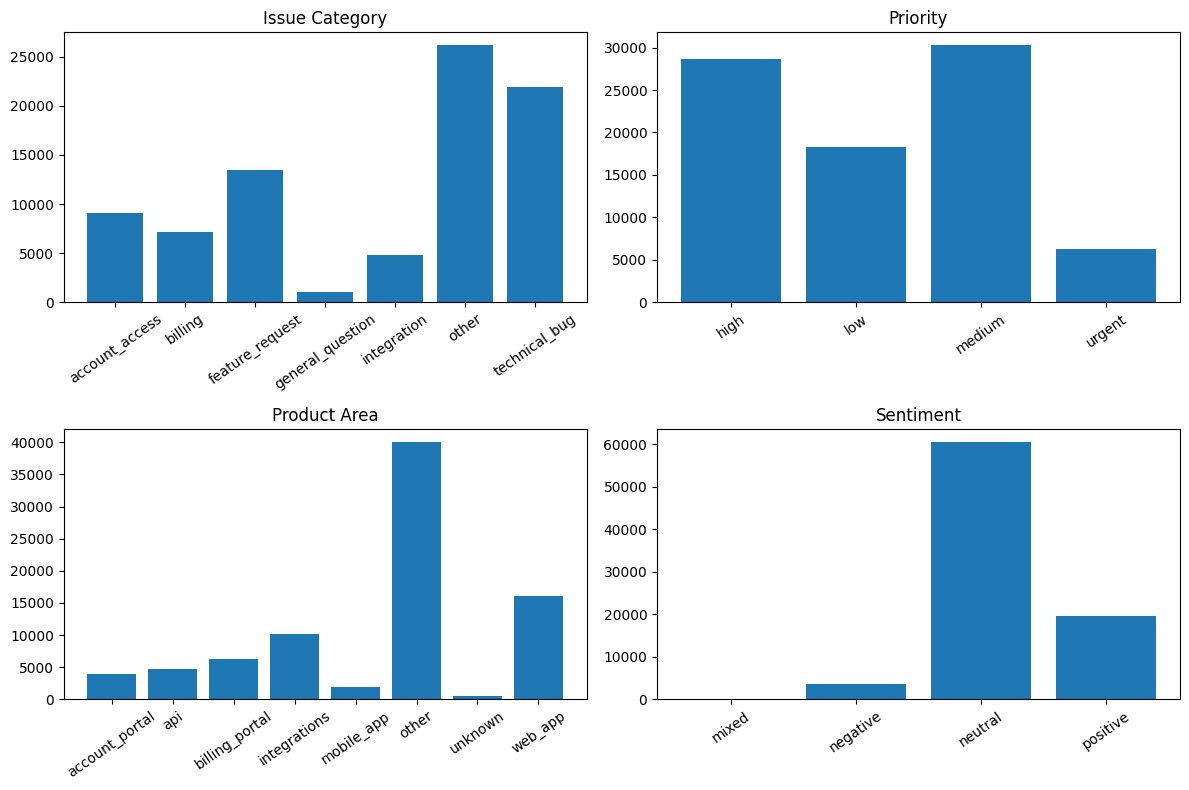

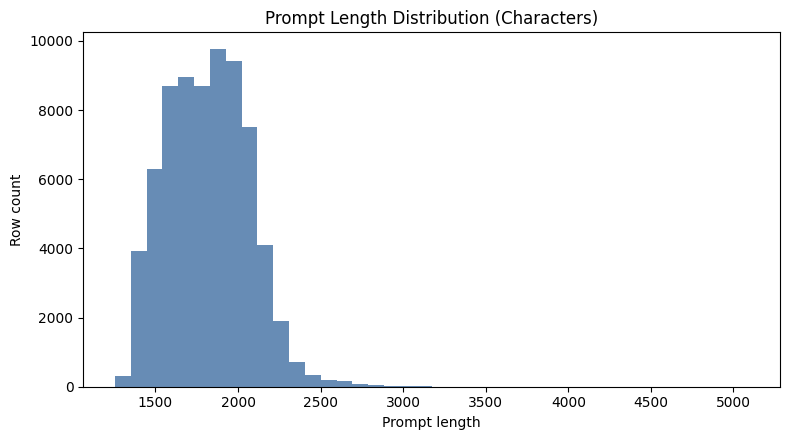

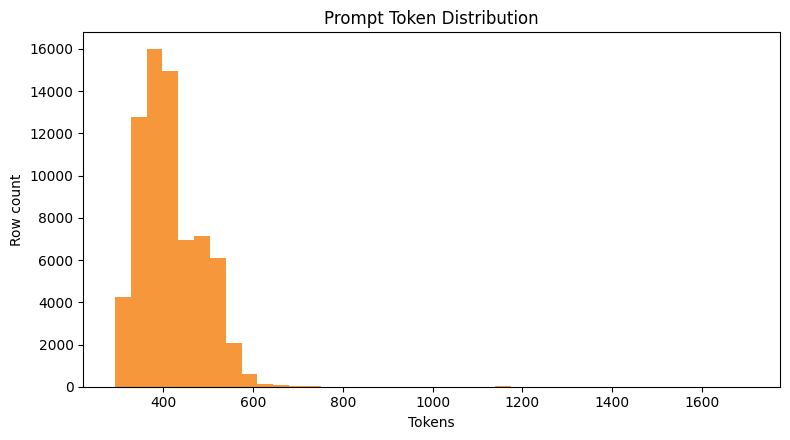

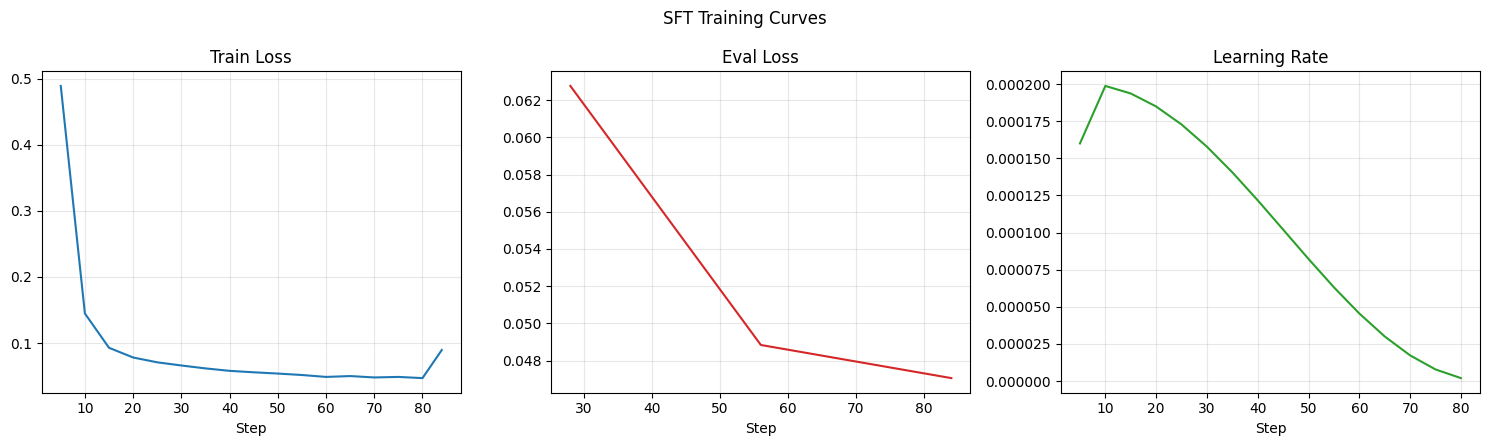

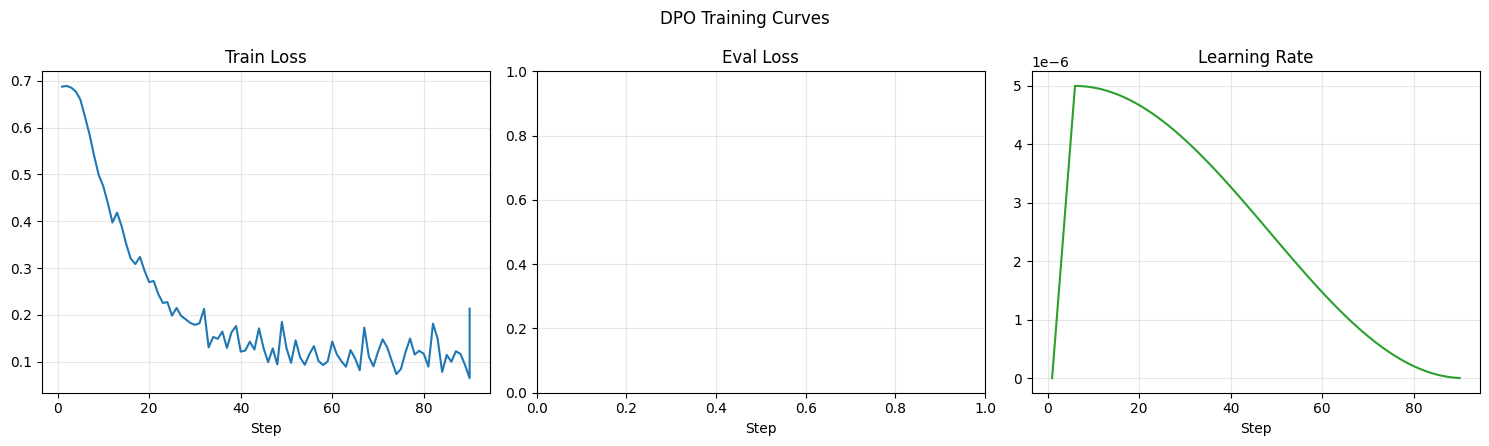

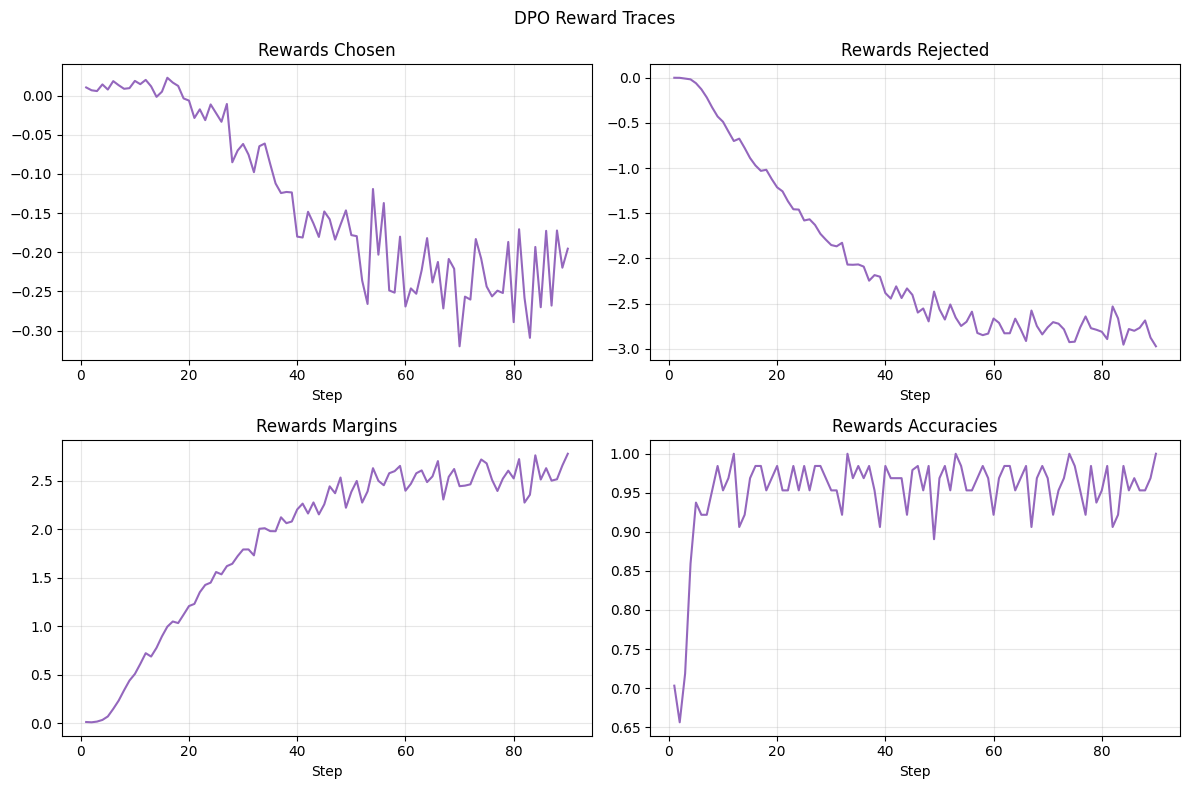

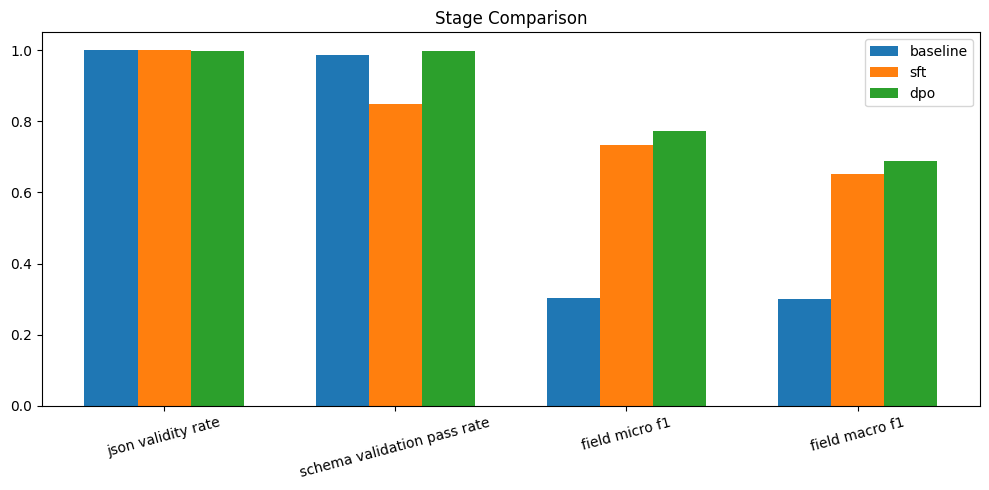

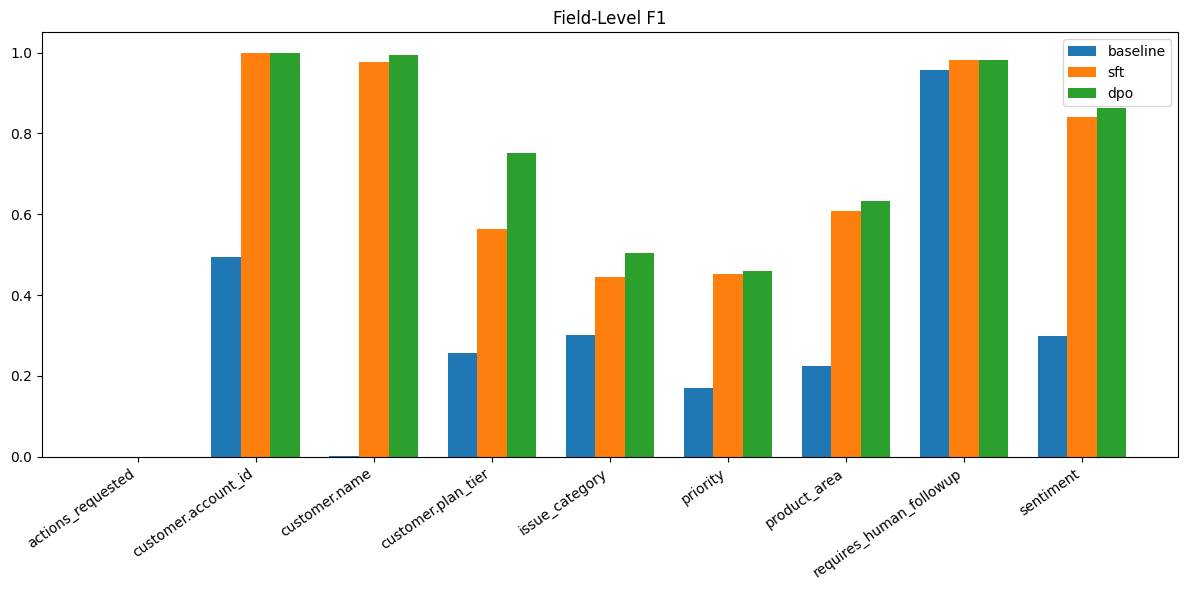

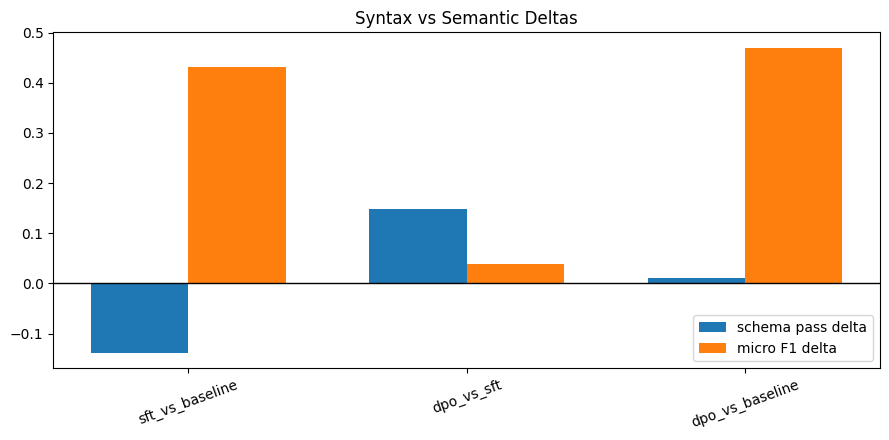

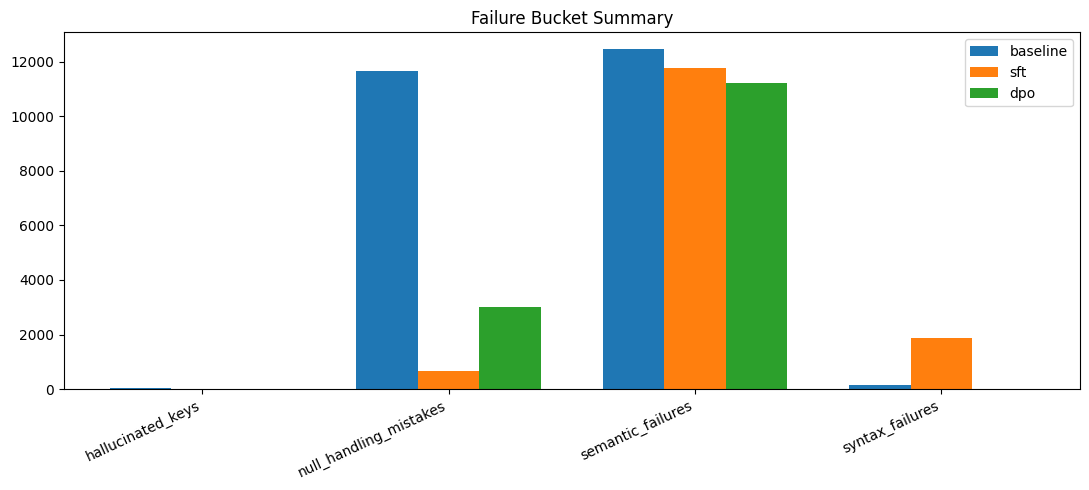

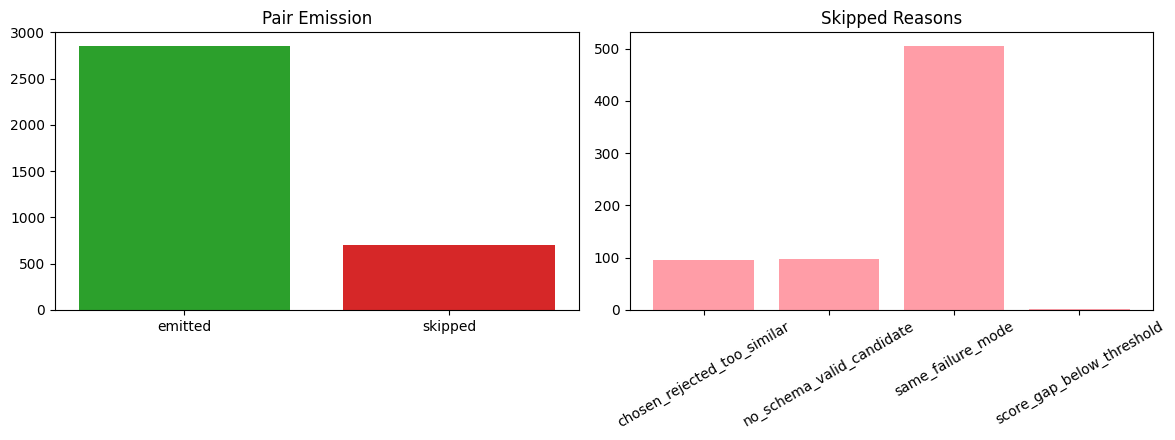

In [18]:
plot_dir = REPO_ROOT / 'artifacts' / 'plots' / 'final_report'
plot_paths = None
try:
    plot_paths = generate_report_plots(bundle, plot_dir)
    display(Markdown(f'Generated plots: `{plot_paths}`'))
except RuntimeError as exc:
    display(Markdown(f'_Plot generation skipped in this environment: {exc}_'))

### Saved Label Distribution Plot

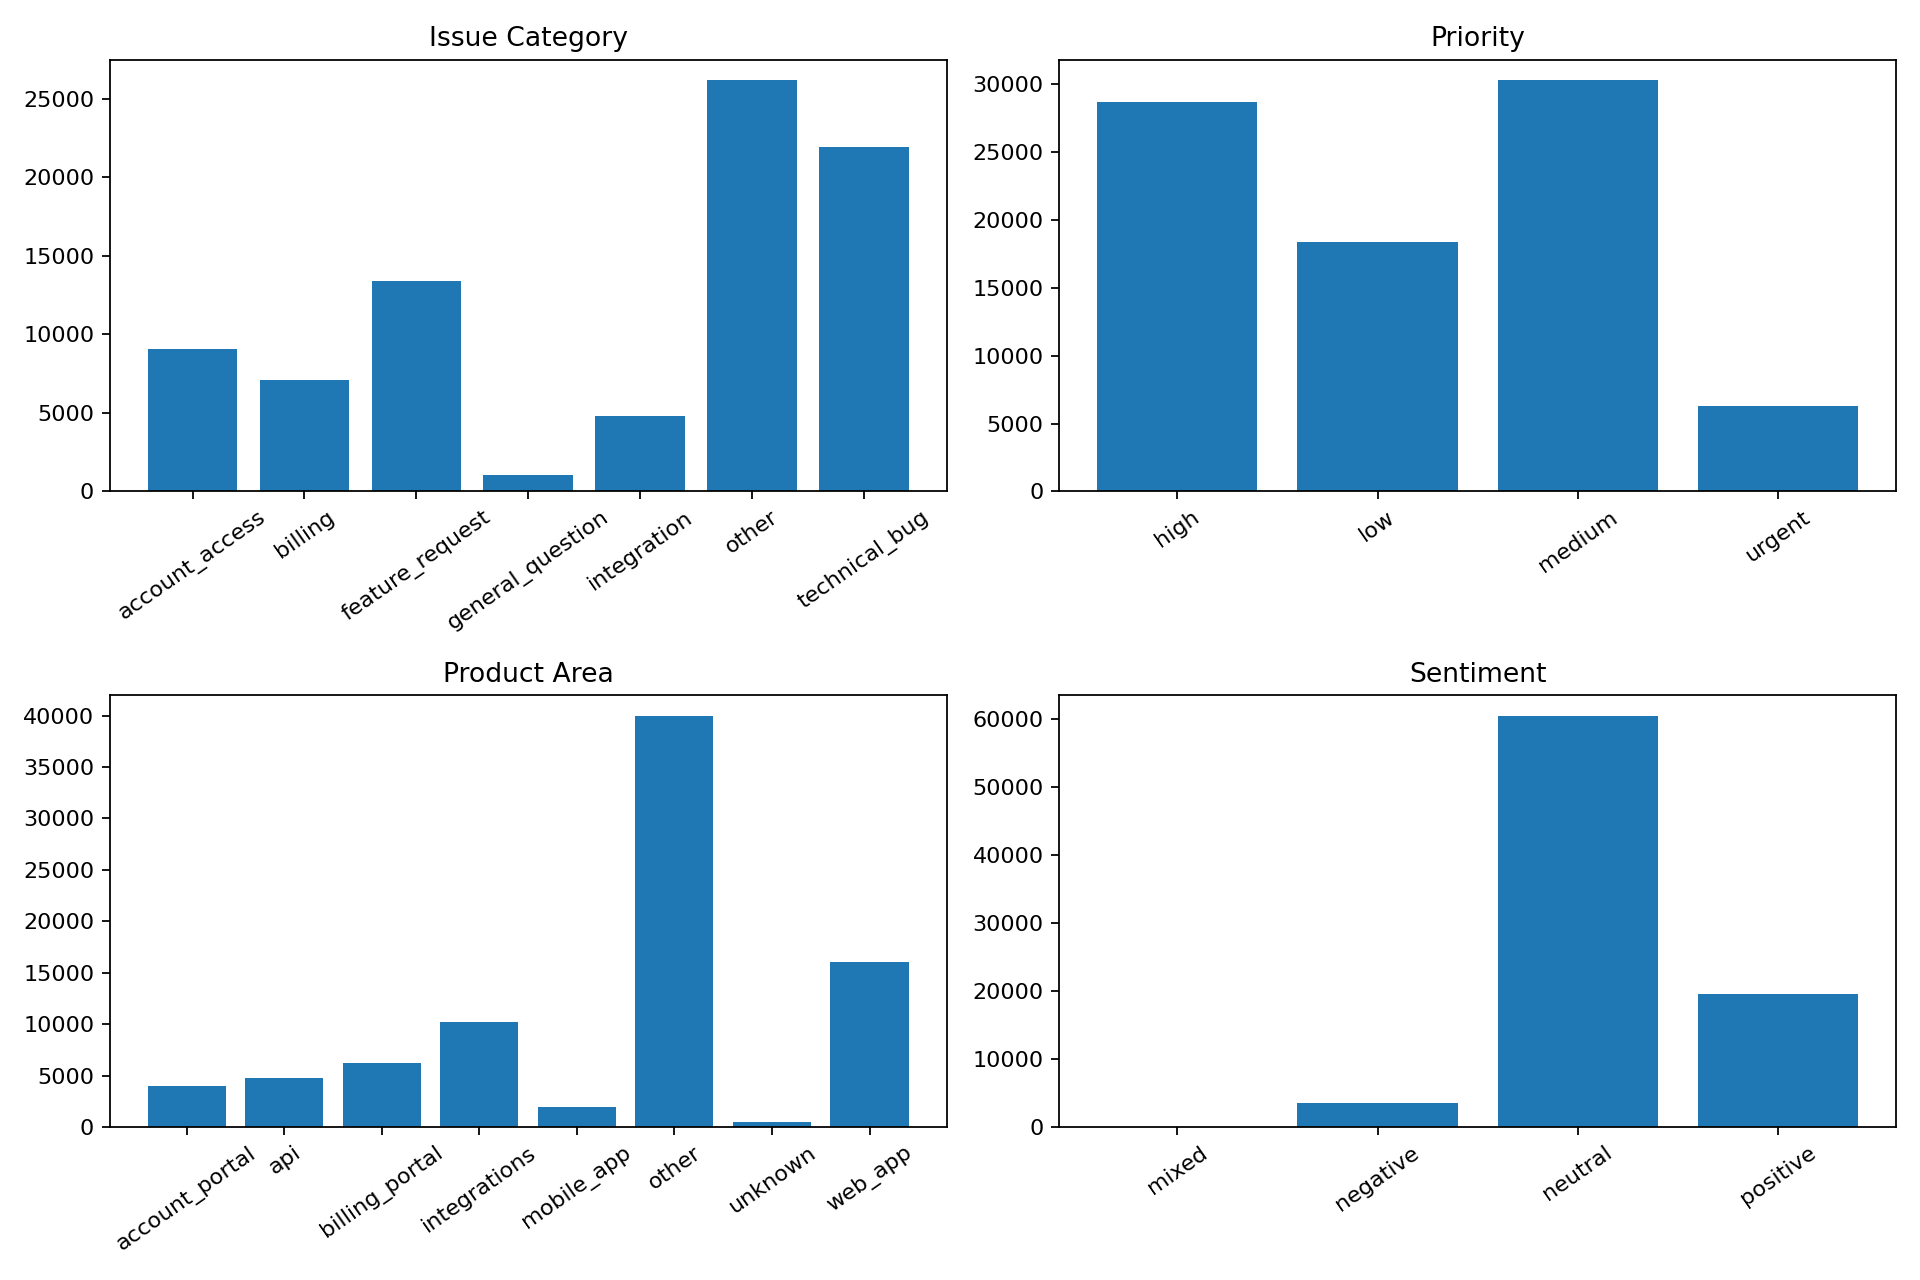

`/content/artifacts/plots/final_report/dataset_label_distribution.png`

### Prompt Length Distribution Plot

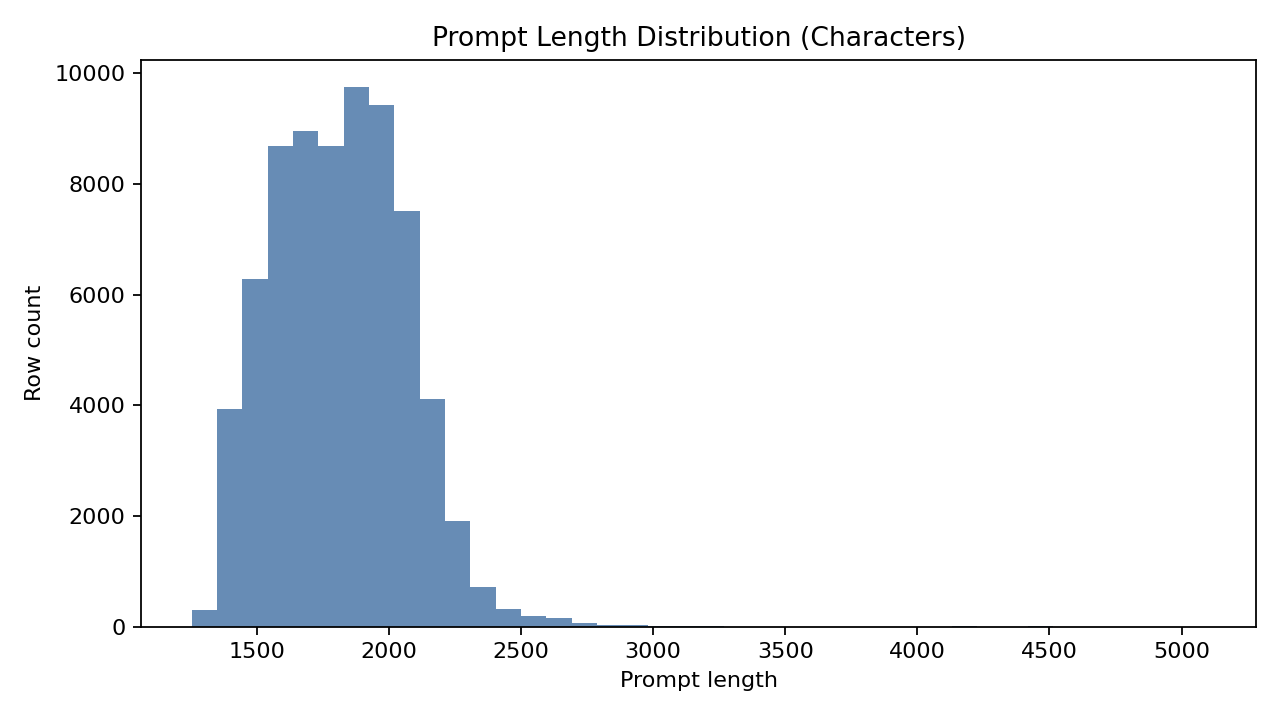

`/content/artifacts/plots/final_report/prompt_length_distribution.png`

### Prompt Token or Length Proxy Distribution Plot

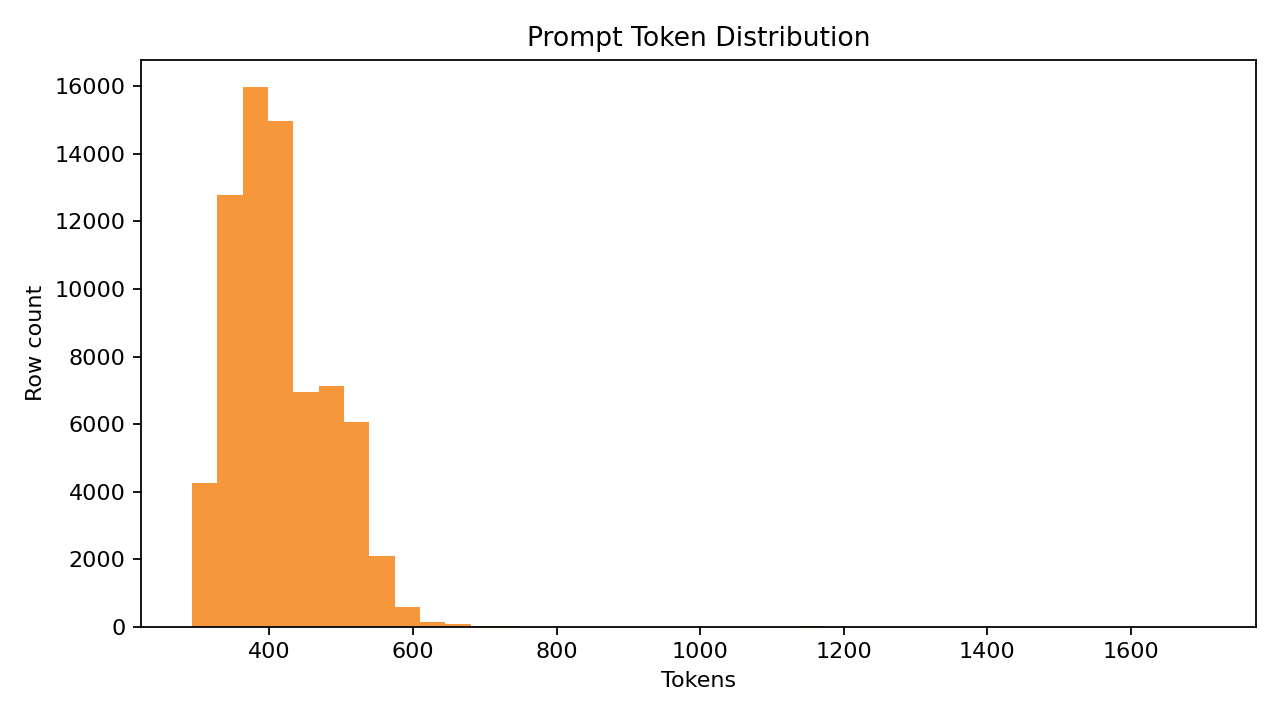

`/content/artifacts/plots/final_report/token_length_distribution.png`

In [19]:
display_plot(plot_paths, 'dataset_label_distribution', 'Saved Label Distribution Plot')
display_plot(plot_paths, 'prompt_length_distribution', 'Prompt Length Distribution Plot')
display_plot(plot_paths, 'token_length_distribution', 'Prompt Token or Length Proxy Distribution Plot')

The label mix looks workable, but not balanced in the clean academic sense. That is fine for this project. The goal is not synthetic balance. The goal is a believable support-ticket extraction environment. Still, the source skew means some field priors are likely learned more strongly than others.

The prompt-length distribution matters because this is a long-context extraction task. The saved prompt-length summary already shows an average of about `1483` characters and a max of `4740`. That makes the task harder than short intent classification. It also helps explain why inference latency is high even before we compare stages.

## Baseline Story

The baseline result is useful because it avoids a common false story. The model already emits JSON-like output reliably. JSON validity is `0.9998`. Schema pass is `0.9876`. So the baseline is not failing as a serializer. It is failing as an extractor and classifier.

The saved confusion-like summaries make that clear. `issue_category` collapses heavily toward `technical_bug`. `priority` leans hard toward `urgent`. `sentiment` overpredicts `negative`. `customer.plan_tier` is often omitted or hallucinated. This is a model that knows how to answer in structure, but does not yet know how to calibrate this schema well.

This matters because a casual review could over-credit the baseline. The output looks clean. But field-level micro F1 is only `0.3030`, and macro F1 is `0.3008`. That gap between clean shape and weak meaning is the core reason the post-training stack is worth doing here.

The likely reason is straightforward. An instruct model starts with strong generic formatting competence. It does not start with sharp task-specific calibration on this schema's routing categories or null-handling behavior. When evidence is thin, it tends to fill something in. That is why syntax is already strong while semantics are weak.

In [20]:
display_table(build_stage_metrics_table(bundle), title='Stage Metrics')
display_table(build_failure_bucket_table(bundle), title='Failure Bucket Summary')
baseline_diag = bundle.baseline.diagnostics or {}
display(Markdown(f"Baseline qualitative note: {baseline_diag.get('qualitative_summary', 'n/a')}"))

### Stage Metrics

stage,json_validity_rate,schema_validation_pass_rate,hallucinated_field_rate,json_recovery_rate,field_level_micro_f1,field_level_macro_f1,latency_mean_ms,latency_p95_ms
baseline,0.9998,0.9876,0.0033,0.0,0.303,0.3008,10760.63,13152.76
sft,0.999,0.8492,0.0,0.0,0.7334,0.6519,10773.13,12375.9
dpo,0.9984,0.9982,0.0,0.0,0.773,0.6871,16000.42,20388.68


### Failure Bucket Summary

bucket,baseline,sft,dpo
hallucinated_keys,41,0,0
null_handling_mistakes,11658,677,2998
semantic_failures,12448,11758,11197
syntax_failures,155,1878,23


Baseline qualitative note: Use the example buckets and per-field diagnostics for qualitative review. The free-text summary field remains qualitative and is not scored as an aggregate metric.

In [21]:
baseline_confusions = (bundle.baseline.diagnostics or {}).get('categorical_confusion_like', {})
for field in ['issue_category', 'priority', 'product_area', 'sentiment', 'customer.plan_tier']:
    display_table(baseline_confusions.get(field, [])[:10], title=f'Baseline Top Confusions: {field}')

### Baseline Top Confusions: issue_category

count,predicted,reference
3809,technical_bug,other
2877,technical_bug,technical_bug
1076,technical_bug,account_access
1062,technical_bug,feature_request
582,technical_bug,integration
569,technical_bug,billing
345,billing,billing
344,integration,feature_request
338,feature_request,feature_request
268,integration,technical_bug


### Baseline Top Confusions: priority

count,predicted,reference
3227,urgent,high
3114,urgent,medium
1606,urgent,low
955,high,medium
921,urgent,urgent
849,high,low
742,high,high
424,medium,medium
301,medium,low
234,medium,high


### Baseline Top Confusions: product_area

count,predicted,reference
2117,billing_portal,other
1661,api,other
1501,web_app,other
985,integrations,integrations
817,web_app,web_app
570,billing_portal,web_app
544,billing_portal,billing_portal
543,api,web_app
413,mobile_app,other
311,integrations,api


### Baseline Top Confusions: sentiment

count,predicted,reference
5659,negative,neutral
2867,neutral,neutral
1179,neutral,positive
1156,negative,positive
608,positive,neutral
451,positive,positive
406,negative,negative
75,mixed,neutral
35,neutral,negative
10,positive,negative


### Baseline Top Confusions: customer.plan_tier

count,predicted,reference
6268,None,pro
2490,None,None
2167,enterprise,pro
685,pro,pro
368,enterprise,None
170,free,pro
118,pro,None
52,business,pro
20,free,None
20,None,free


The failure buckets reinforce the same story. Only `155` rows are syntax failures. But `12,448` rows are semantic failures, and `11,658` rows have null-handling mistakes. The baseline is mostly producing well-formed answers that say the wrong thing or guess too much.

This is one of the strongest parts of the project story. It shows why syntax quality and semantic quality must stay separate. If we merged them into one vague quality claim, the baseline would look much better than it really is.

## SFT Story

SFT is the main semantic improvement stage in the saved artifact trail. The metric jump is large. Micro F1 moves from `0.3030` to `0.7334`. Macro F1 moves from `0.3008` to `0.6519`. That is the biggest step change in the whole project.

The training telemetry supports that this is real learning, not just formatting memorization. Saved SFT train loss falls from about `0.489` to `0.089`. Eval loss also drops from about `0.0628` to `0.0471`. The run only used a deterministic `10%` subset of train rows for the saved training pass, so these gains are meaningful but likely not saturated.

The field pattern also matters. The saved eval report shows especially strong gains in `customer.name`, `customer.account_id`, `sentiment`, `product_area`, and `customer.plan_tier`. Null-handling mistakes collapse from `11,658` to `677`. That is a major behavioral change. It suggests the model learned the schema and the domain labels much more directly.

The downside is sharp. Schema pass falls from `0.9876` to `0.8492`. JSON validity only slips a little, but schema validity drops a lot. This means SFT improved field prediction while weakening output discipline.

The likely reason is that the model learned the target task faster than it learned to stay structurally conservative. It became better at predicting fields, but also more willing to emit incomplete or slightly malformed schema outputs. That tradeoff is plausible for supervised fine-tuning on a narrow extraction task.

In [22]:
display_table(build_stage_delta_table(bundle), title='Saved Stage Deltas')
display(Markdown(f"SFT summary path: `{bundle.sft.summary_path}`"))
display(Markdown(f"SFT history path: `{bundle.sft.history_path}`"))

### Saved Stage Deltas

comparison,hallucinated_field_rate,json_recovery_rate,json_validity_rate,schema_validation_pass_rate,field_level_macro_f1,field_level_micro_f1
sft_vs_baseline,-0.0033,0.0,-0.0009,-0.1384,0.3511,0.4305
dpo_vs_sft,0.0,0.0,-0.0006,0.149,0.0352,0.0396
dpo_vs_baseline,-0.0033,0.0,-0.0014,0.0106,0.3863,0.47


SFT summary path: `/content/drive/MyDrive/json-ft-source/artifacts/metrics/sft-full-colab_sft_summary.json`

SFT history path: `/content/drive/MyDrive/json-ft-source/artifacts/metrics/sft-full-colab_sft_history.json`

### SFT Training Curves

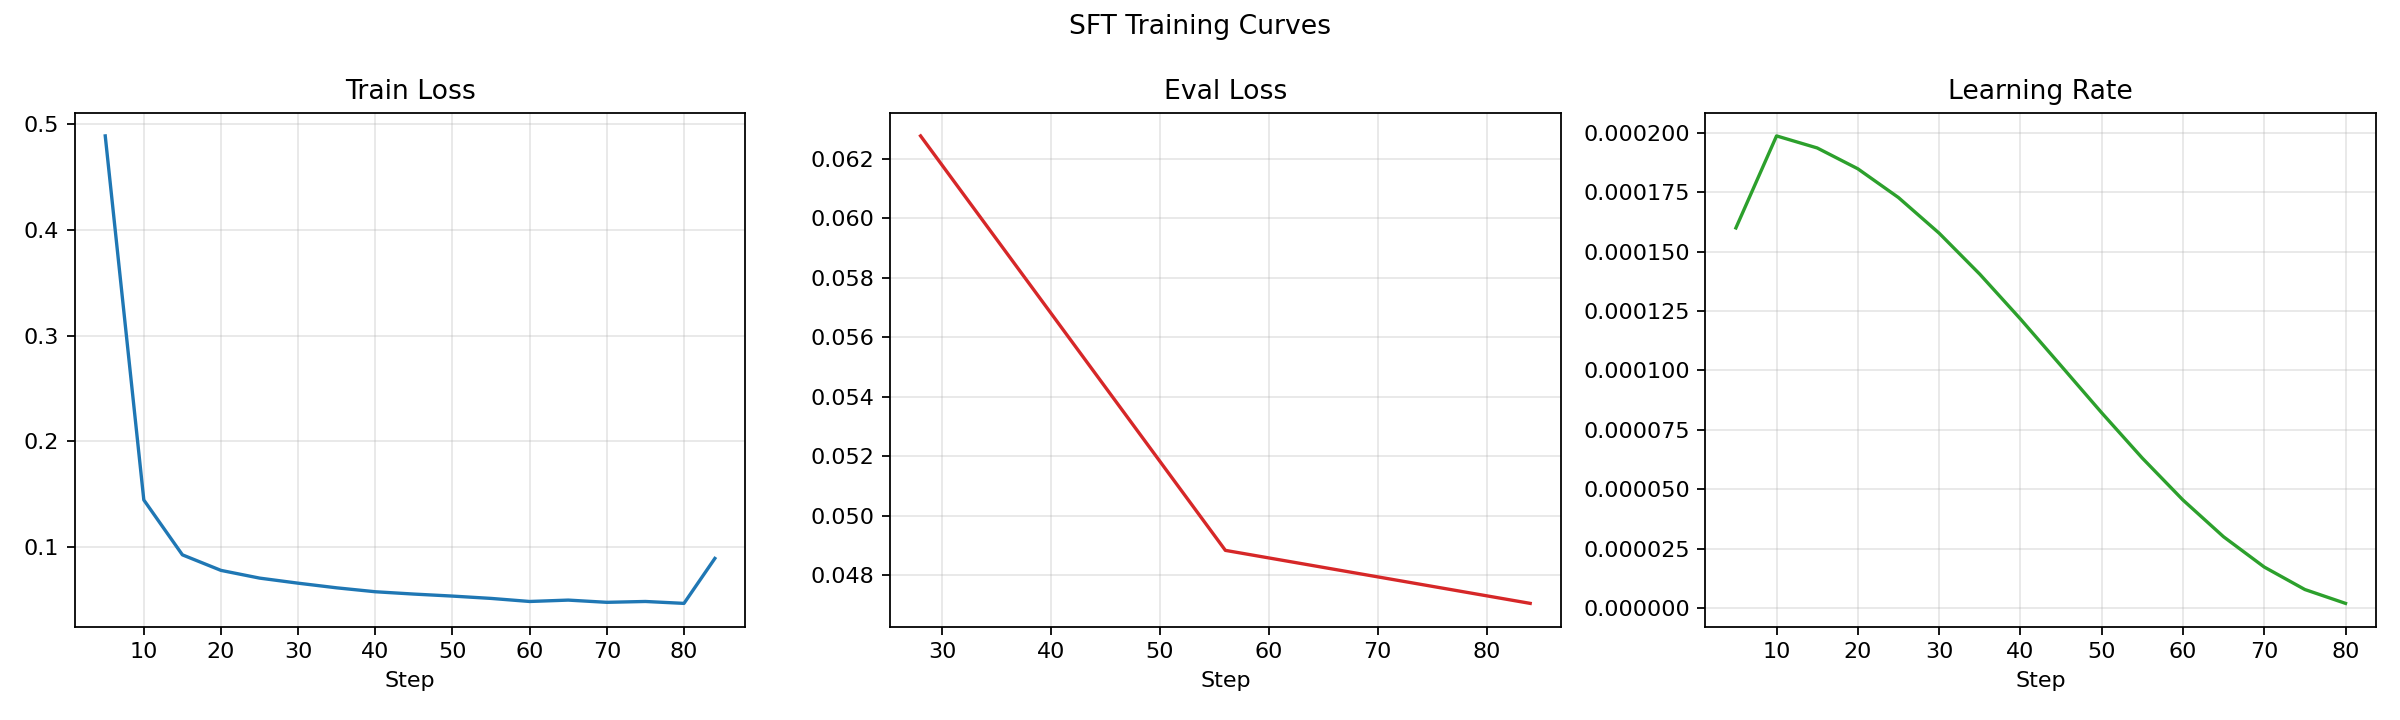

`/content/artifacts/plots/final_report/sft_training_curves.png`

In [23]:
display_plot(plot_paths, 'sft_training_curves', 'SFT Training Curves')

The SFT curves read the way we want them to read. Train loss falls hard. Eval loss also trends down. That suggests genuine learning on the task, not just memorized answer shape. This matters because the baseline was already good at shape.

There is still a limit here. The saved run used only a sampled subset of train data. So the current SFT result is strong evidence that the data and supervision contract work, not proof that the training stage is already fully optimized.

## Preference Optimization and DPO Story

DPO in this repo is not broad RLHF. It is a narrow preference pass over chosen and rejected structured outputs derived from the same extraction task. That matters because the interpretation should stay narrow too. We are not asking whether DPO makes the model more generally aligned. We are asking whether it cleans up this task.

The trainer-side telemetry is strong. DPO train loss falls from about `0.688` to `0.213`. Reward margin grows from about `0.011` to `2.777`. Reward accuracy rises from about `0.703` to `1.0`. So the model clearly learned the preference signal.

But that is not the headline. The headline is held-out eval. DPO repairs schema discipline very strongly and adds a smaller semantic improvement over SFT. Schema pass rebounds from `0.8492` to `0.9982`. Micro F1 improves from `0.7334` to `0.7730`. Macro F1 improves from `0.6519` to `0.6871`.

The cost is real. Mean latency rises from about `10.8s` to `16.0s`. The diagnostics are also mixed. Syntax failures collapse from `1,878` to `23`, which is a major repair. But null-handling mistakes worsen from `677` to `2,998`. So DPO corrected structure more strongly than it corrected every semantic tendency.

The likely explanation is that DPO is very effective at rewarding better-formed, schema-safe outputs. It appears less uniformly effective at preserving every semantic win from SFT. That is exactly why this report should not oversell DPO as a universal improvement.

In [24]:
display_table(build_pair_quality_table(bundle), title='Pair Quality Summary')
display_table(build_field_level_table(bundle, metric='f1'), title='Field-Level F1 Across Stages')

### Pair Quality Summary

scope,source_row_count,pair_count,pair_emission_rate,candidate_json_valid_rate,candidate_schema_pass_rate,chosen_schema_valid_rate,rejected_schema_valid_rate,average_numeric_score_gap
overall,3558,2858,0.8033,0.9976,0.7063,1.0,0.0595,8.9677
console_ai_it_helpdesk_synthetic_tickets,18,15,0.8333,,,,,
prady06_customer_support_tickets,2471,1981,0.8017,,,,,
synthetic_hardening_v1,1069,862,0.8064,,,,,


### Field-Level F1 Across Stages

field,baseline,sft,dpo,sft_delta_vs_baseline,dpo_delta_vs_sft,dpo_delta_vs_baseline
actions_requested,0.0,0.0,0.0,0.0,0.0,0.0
customer.account_id,0.4948,0.9995,0.9992,0.5047,-0.0003,0.5044
customer.name,0.003,0.9757,0.9931,0.9727,0.0174,0.9901
customer.plan_tier,0.257,0.5639,0.7521,0.3069,0.1882,0.4951
issue_category,0.3022,0.4457,0.5035,0.1435,0.0578,0.2013
priority,0.1695,0.4527,0.4605,0.2832,0.0078,0.291
product_area,0.2238,0.6089,0.6329,0.3851,0.024,0.4091
requires_human_followup,0.958,0.9812,0.9809,0.0232,-0.0003,0.023
sentiment,0.2991,0.8398,0.862,0.5407,0.0222,0.5628


### DPO Loss Curves

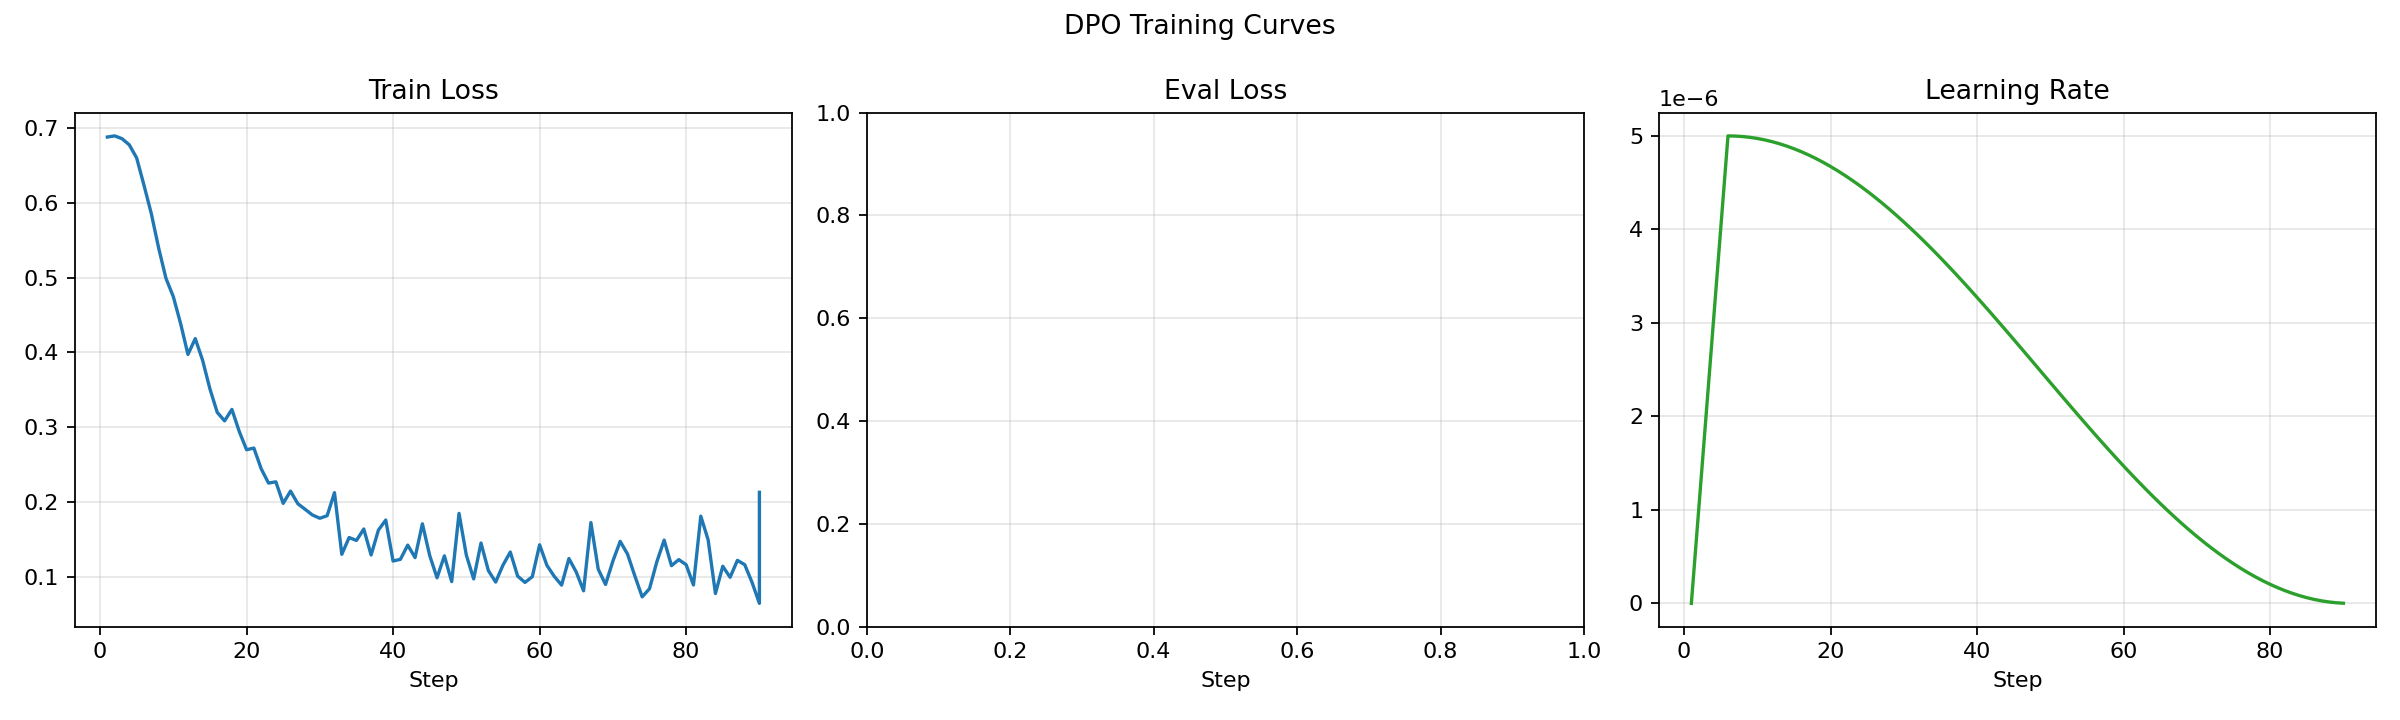

`/content/artifacts/plots/final_report/dpo_training_curves.png`

### DPO Reward Curves

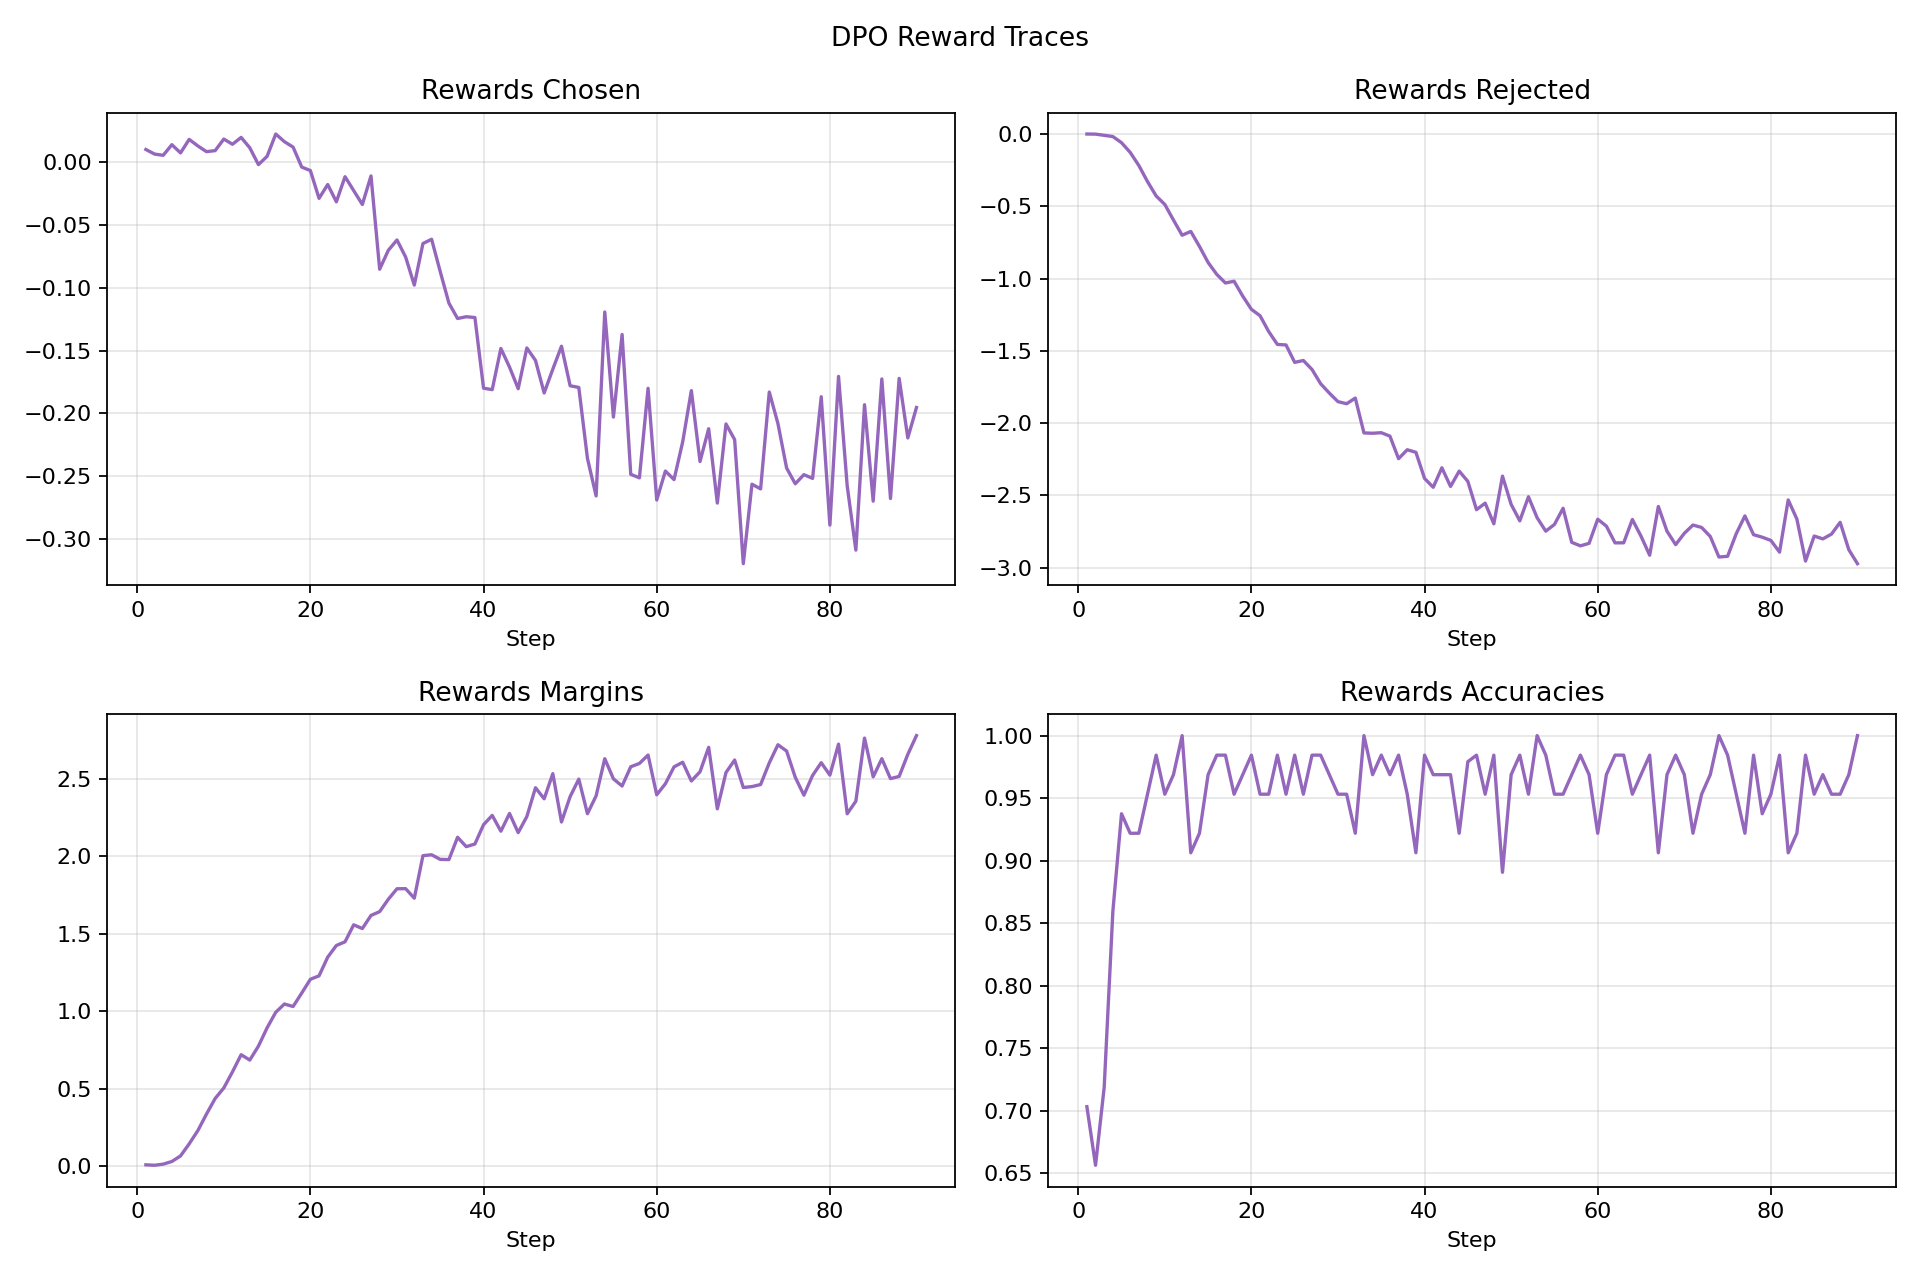

`/content/artifacts/plots/final_report/dpo_reward_curves.png`

### Preference Diagnostics Plot

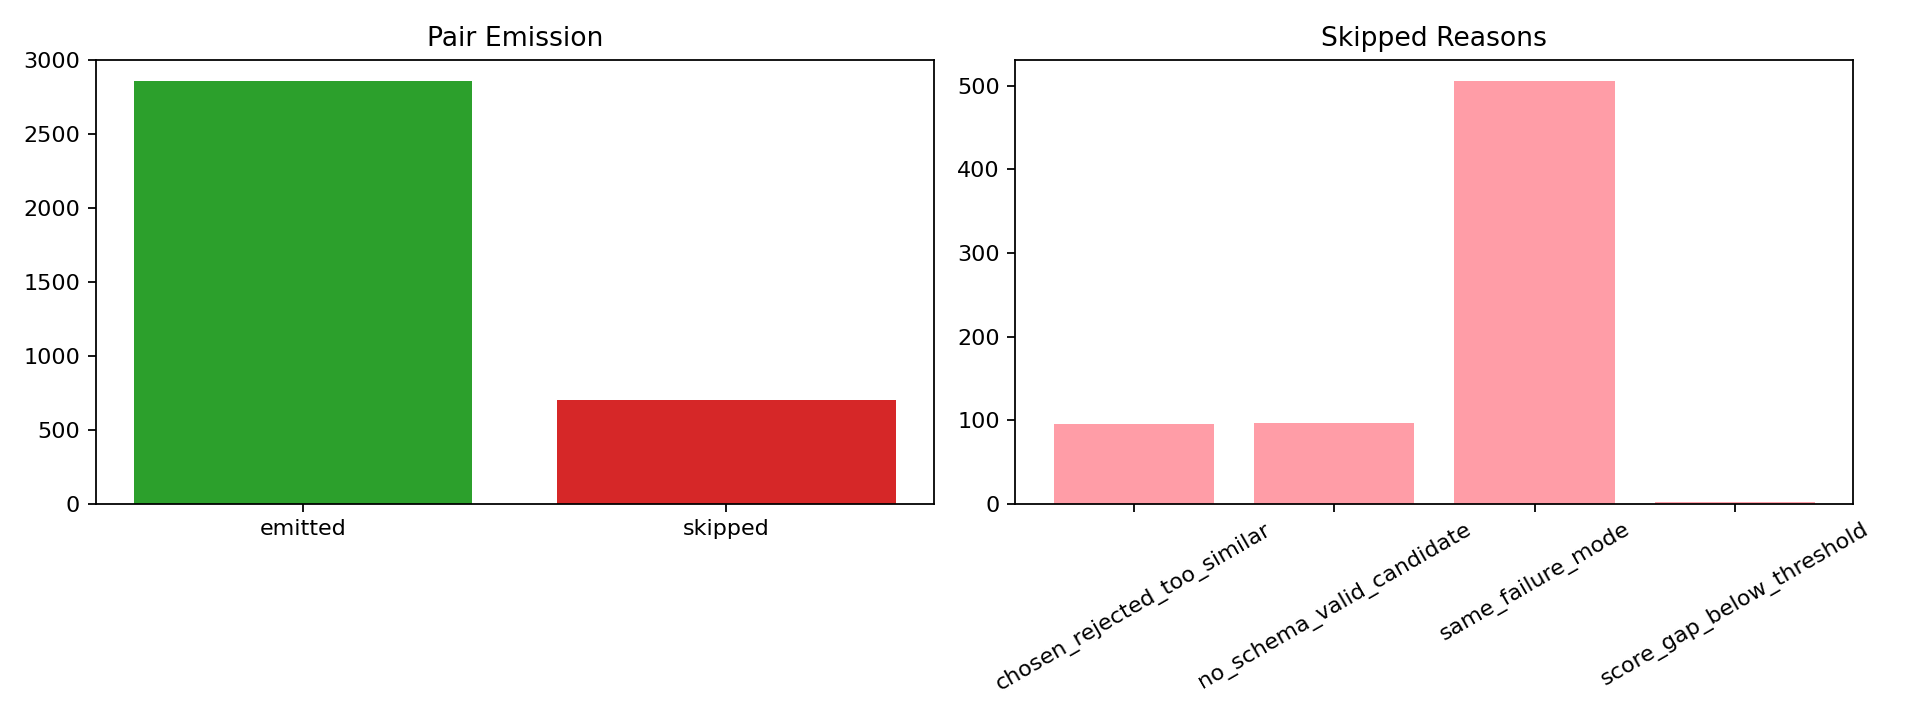

`/content/artifacts/plots/final_report/preference_diagnostics.png`

In [25]:
display_plot(plot_paths, 'dpo_training_curves', 'DPO Loss Curves')
display_plot(plot_paths, 'dpo_reward_curves', 'DPO Reward Curves')
display_plot(plot_paths, 'preference_diagnostics', 'Preference Diagnostics Plot')

The DPO reward curves show that the model learned the preference objective. Rising reward margin and reward accuracy are exactly what we would expect if chosen outputs are being separated from rejected ones more consistently over training.

This still needs held-out evaluation to matter. A cleaner reward curve is not enough on its own. In this project, the trainer-side reward traces are supporting evidence. The real evidence is the combination of near-complete schema-pass recovery and a smaller but real semantic gain over SFT.

The preference section should stay cautious until the full `pref-full-colab` artifacts are loaded from Drive. Without those files, we should not make strong claims about pair quality. The right statement is narrower: the saved DPO training and eval artifacts suggest that the preference stage was useful, but the full audit trail still belongs in the notebook if the Drive files exist.

## Final Comparison

The high-level story is now clear. Baseline to SFT is the big semantic shift. SFT to DPO is mostly a structure-and-calibration repair step plus a modest semantic lift. DPO beats baseline overall, but the path matters.

This matters because the project is not claiming that every post-training stage does the same thing. SFT creates most of the task competence. DPO makes the resulting system more usable by repairing structure and adding some extra semantic lift, but it also introduces cost and some new weaknesses.

### Stage Comparison Plot

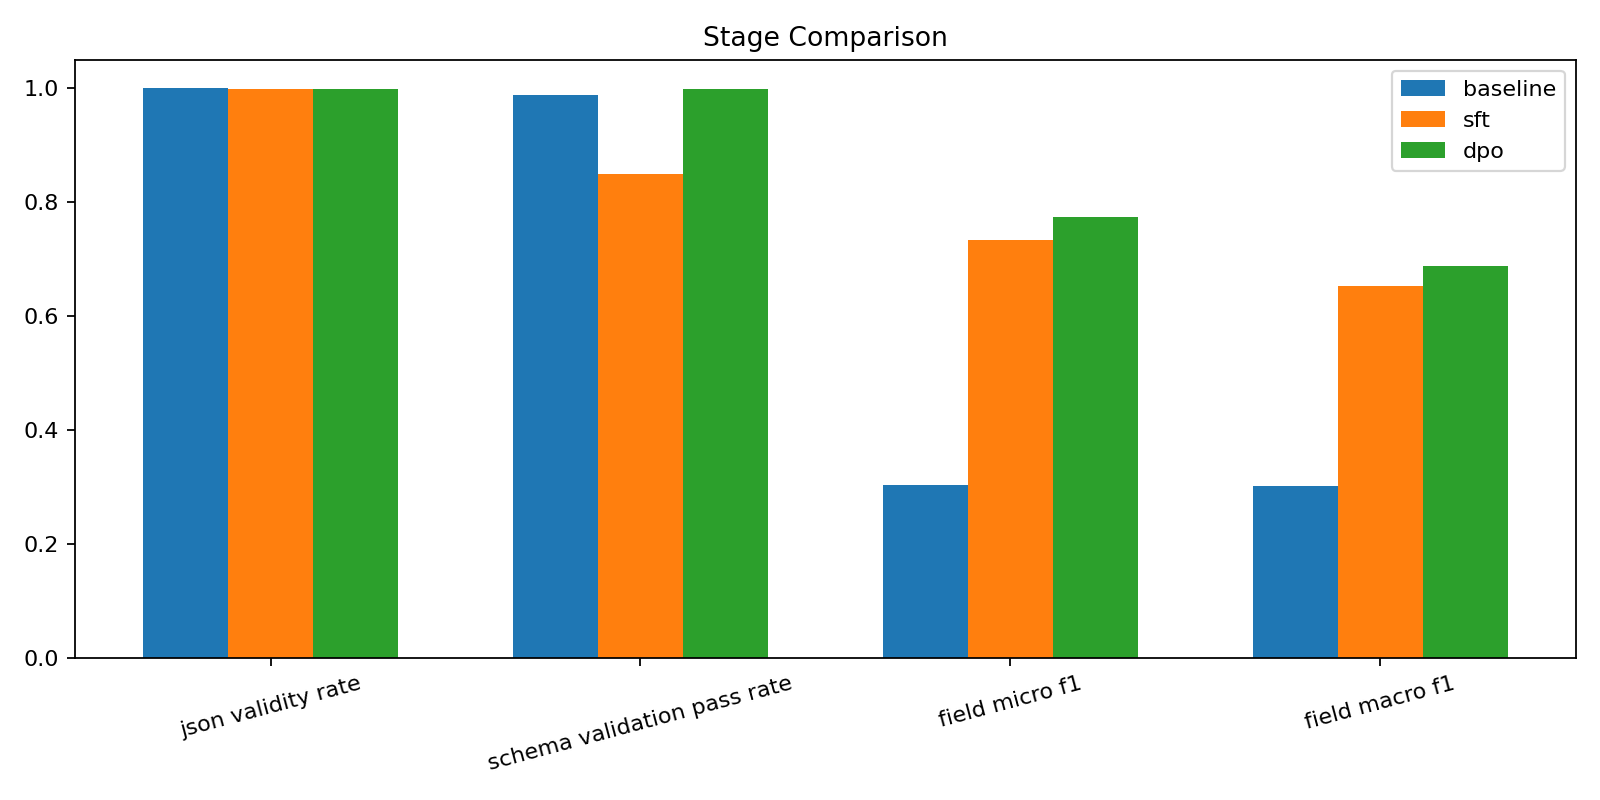

`/content/artifacts/plots/final_report/stage_comparison.png`

### Field-Level F1 Plot

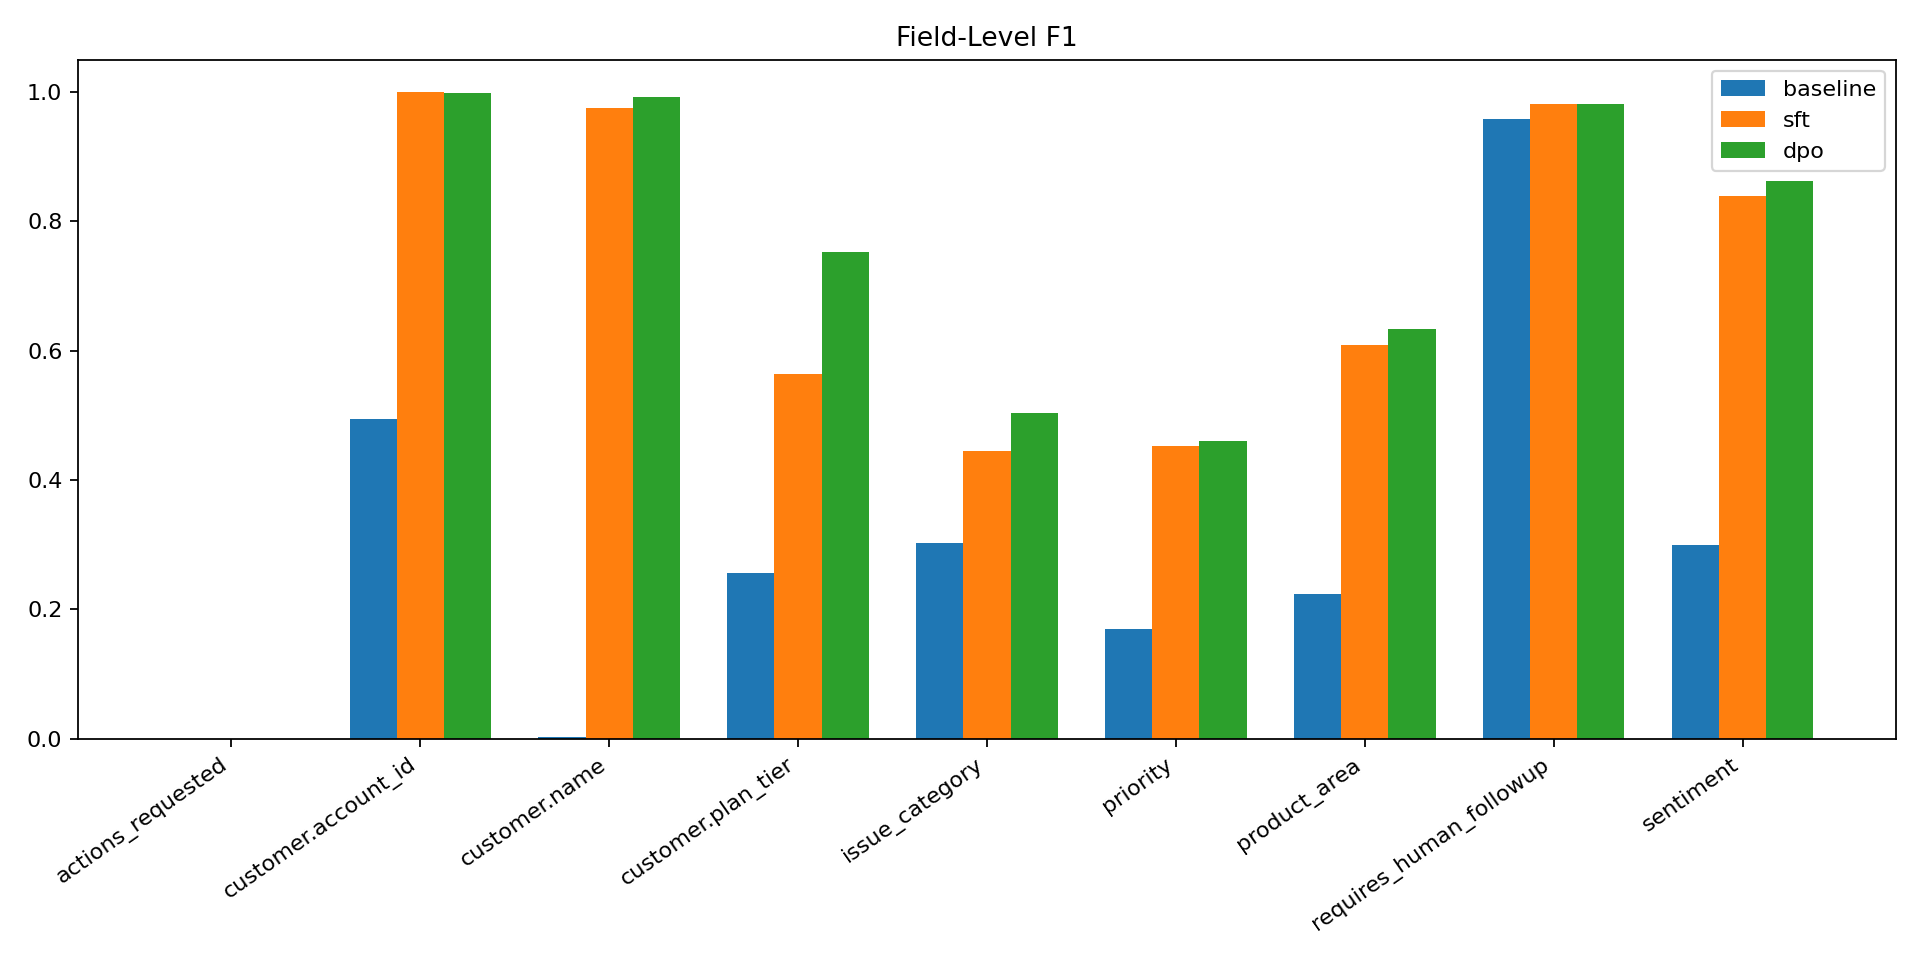

`/content/artifacts/plots/final_report/field_level_f1.png`

### Syntax vs Semantic Deltas Plot

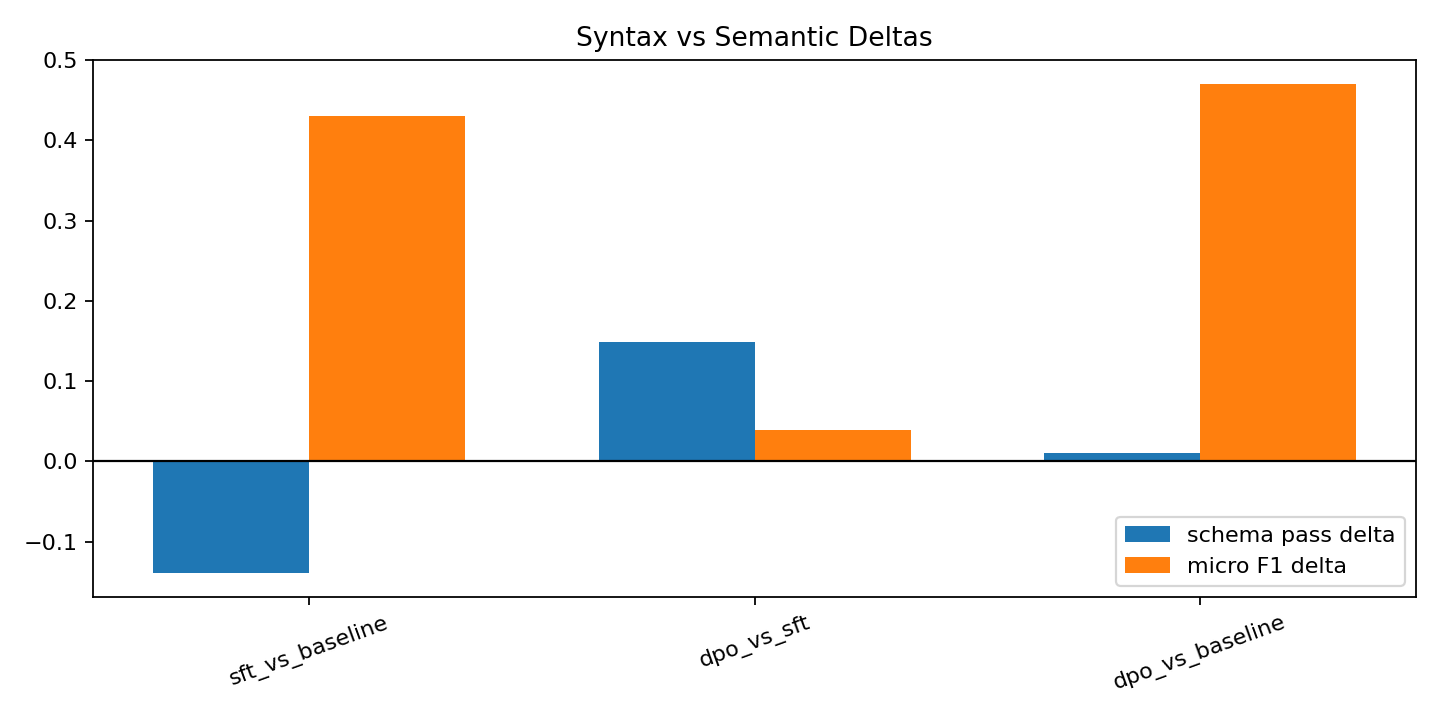

`/content/artifacts/plots/final_report/syntax_semantic_deltas.png`

### Failure Bucket Plot

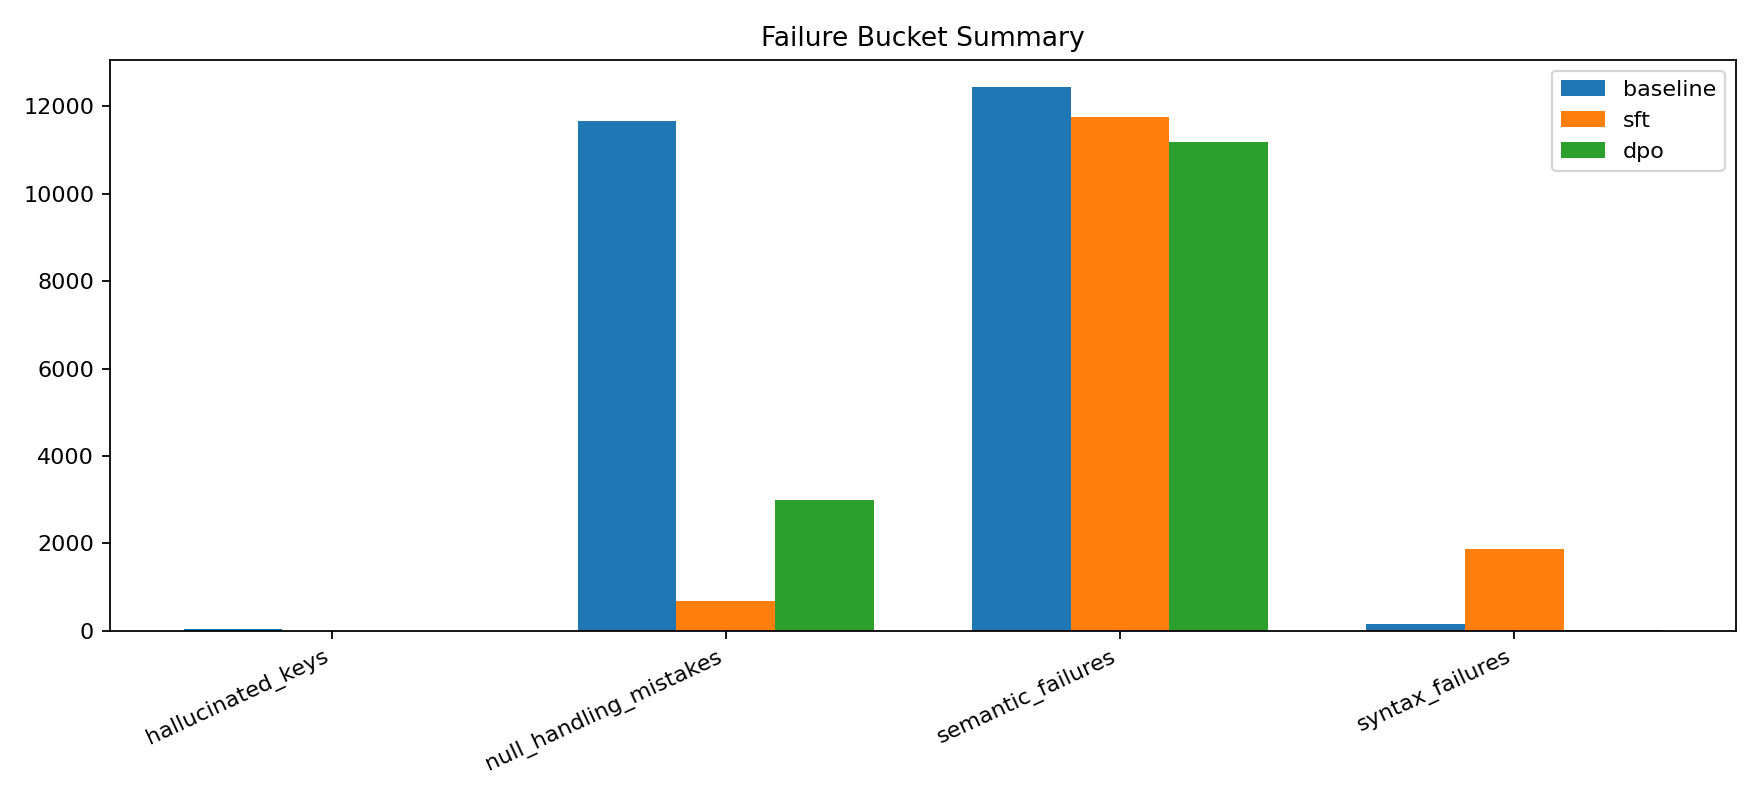

`/content/artifacts/plots/final_report/failure_buckets.png`

In [26]:
display_plot(plot_paths, 'stage_comparison', 'Stage Comparison Plot')
display_plot(plot_paths, 'field_level_f1', 'Field-Level F1 Plot')
display_plot(plot_paths, 'syntax_semantic_deltas', 'Syntax vs Semantic Deltas Plot')
display_plot(plot_paths, 'failure_buckets', 'Failure Bucket Plot')

The stage comparison plot should be read in two passes. First, look at the syntax axis. That is where DPO's biggest relative contribution shows up. Second, look at the semantic axis. That is where SFT already did most of the heavy lifting. The story is not "everything improved." The story is "different things improved at different stages."

The field-level plot should also be read unevenly. DPO likely helps `customer.plan_tier` a lot. That fits the saved exact-match and per-field metrics. `priority` improves much less. That suggests some routing ambiguity remains even after preference optimization.

The failure bucket plot says the same thing from the other direction. SFT traded syntax robustness for semantic gain. DPO repaired syntax failures strongly. DPO did not remove all semantic errors. Null-handling got worse again after DPO, so the improvement is real but not uniform.

## Case Studies

This section is where the current local repo mirror is weakest. The notebook needs the Drive-backed SFT and DPO prediction files to make these examples real. Without those files, the report can explain the aggregate pattern but cannot yet show the strongest row-level before and after examples in one place.

That is why the Drive fetch cells sit near the top of the notebook. Once those files are available in Colab, this section should become the most concrete part of the report. Each bucket should show a few rows and then one short synthesis paragraph on what that bucket means.

In [27]:
case_studies = extract_case_studies(bundle)
display_case_studies(case_studies, 'baseline_bad_to_sft_good', 'Baseline Bad -> SFT Good')
display_case_studies(case_studies, 'sft_good_to_dpo_better', 'SFT Good -> DPO Better')
display_case_studies(case_studies, 'sft_good_to_dpo_worse', 'SFT Good -> DPO Worse')
display_case_studies(case_studies, 'syntax_cleaned_up_semantics_unchanged', 'Syntax Cleaned Up But Semantics Unchanged')
display_case_studies(case_studies, 'unchanged_hard_failures', 'Unchanged Hard Failures')

### Baseline Bad -> SFT Good

_No saved row-level example was available for this category in the current artifact set._

### SFT Good -> DPO Better

_No saved row-level example was available for this category in the current artifact set._

### SFT Good -> DPO Worse

_No saved row-level example was available for this category in the current artifact set._

### Syntax Cleaned Up But Semantics Unchanged

_No saved row-level example was available for this category in the current artifact set._

### Unchanged Hard Failures

_No saved row-level example was available for this category in the current artifact set._

When the Drive-backed predictions load, the five buckets will matter for different reasons.

- **Baseline bad -> SFT good** should show why SFT mattered at all.
- **SFT good -> DPO better** should show where DPO adds real value beyond structure repair.
- **SFT good -> DPO worse** should keep the report honest about regressions.
- **Syntax cleaned up but semantics unchanged** should stop us from overstating structural cleanup.
- **Unchanged hard failures** should show what still needs better data, better preference construction, or a different modeling decision.

If these buckets remain empty locally, that is not a story problem. It is an artifact-availability problem. The notebook is now set up to solve that cleanly in Colab.

## Honest Conclusion

The saved artifact trail supports a clear conclusion. The baseline already had syntax. It did not have reliable task fit. SFT is the stage that created most of the semantic competence. That is why the biggest jump in micro and macro F1 happens there.

DPO then made the system more usable and more defensible. It repaired schema discipline almost completely and added a smaller semantic gain on top of SFT. But it did not do this for free. Latency got worse. Some regressions remain. Null-handling also moved in the wrong direction again.

So the blunt but fair bottom line is this: for this task, DPO looks useful as a second-stage cleanup and calibration step, not as the stage that creates the main semantic competence.

The next step is not more narrative. It is deployment discipline. The repo now needs a serving and benchmark lab that compares the best deployable checkpoint on both quality and latency.

In [28]:
report_path = render_final_markdown_report(
    bundle=bundle,
    case_studies=case_studies,
    output_path=REPO_ROOT / 'artifacts' / 'reports' / 'final_project_report.md',
    plot_paths=plot_paths,
)
display(Markdown(f'Final markdown report written to `{report_path}`'))

Final markdown report written to `/content/artifacts/reports/final_project_report.md`